# Phase 2 · 5단원 — 서포트 벡터 머신 (SVM)

> **두 무리 사이에 가장 넓은 길을 내는 것. 이게 SVM의 전부입니다.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/05-support-vector-machines>
- 예상 시간: 90분 · 선수 지식: 1~3단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **힌지 손실**과 경사하강법으로 선형 SVM을 밑바닥부터 만듭니다.
2. **최대 마진**이 뭔지 설명하고, 학습된 모델에서 **서포트 벡터**를 찾아냅니다.
3. **선형·다항·RBF 커널**을 비교하고, 커널 트릭이 어떻게 "고차원에 안 가고도 고차원 계산"을 하는지 이해합니다.
4. **C 값**이 만드는 맞바꿈(길 폭 ↔ 실수 개수)을 직접 확인합니다.

### 🔑 4단원까지와 뭐가 다른가요?

| | 3단원 (로지스틱) | 4단원 (트리) | 5단원 (SVM) |
| --- | --- | --- | --- |
| 목표 | 확률을 잘 맞히기 | 잘 나누는 질문 찾기 | **길을 가장 넓게 내기** |
| 경계 모양 | 직선 | 계단 | **직선 + (커널 쓰면) 곡선** |
| 쓰는 점 | 전부 | 전부 | **가장자리 몇 개만** |
| 손실 | 크로스 엔트로피 | 지니/엔트로피 | **힌지 손실** |

> **핵심 한 줄: 로지스틱 회귀는 "선만 그으면 됨", SVM은 "선을 긋되 양쪽에 최대한 여유를 두고 그음"입니다.**

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 선은 무한히 많은데 뭘 고르지? | 📗 원문 + ✨ 그림 |
| 1 | 🔑 마진 — 길 폭을 재는 법 | 📗 원문 + ✨ 손 계산 |
| 2 | 서포트 벡터 — 소수의 결정권자 | 📗 원문 + ✨ 실험 |
| 3 | 소프트 마진과 C — 실수를 봐주기 | 📗 원문 + ✨ 실험 |
| 4 | 🔑 힌지 손실 | 📗 원문 + ✨ 그림 비교 |
| 5 | 🔨 선형 SVM을 밑바닥부터 | 📗 원문 |
| 6 | 🔨 서포트 벡터 찾기 · 마진 폭 재기 | 📗 원문 |
| 7 | 🔑 커널 트릭 — 안 가고도 갔다 오기 | 📗 원문 + ✨ 3D 그림 |
| 8 | 🔨 커널 SVM 만들기 (SMO) | 📗 원문 + ✨ 구현 |
| 9 | SVR — 숫자를 예측하는 SVM | 📗 원문 |
| 10 | 실무 — sklearn과 스케일링 | 📗 원문 |
| 11 | SVM은 왜 딥러닝에 밀렸나 | 📗 원문 |
| 12 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.
> **특히 4절 힌지 손실이 "왜 갑자기 손실이?" 싶을 수 있는데, 3절에서 곧바로 이어집니다.**

**0절**에서 두 무리를 가르는 선이 **무한히 많다**는 걸 봅니다.
**1절**에서 SVM의 답을 정합니다. **"가장 넓은 길을 내는 선을 고르자."**

- **1절 🔑 마진** — 길 폭이 정확히 $2/\|\mathbf{w}\|$ 임을 봅니다.
  그러니 목표는 **$\|\mathbf{w}\|$를 최소화**하는 것이 됩니다.
- **2절 서포트 벡터** — 길을 최대로 벌리고 나면 **길가에 걸친 점 몇 개**만 경계를 결정합니다.
  나머지는 지워도 됩니다. **그런데 왜 그런지는 아직 설명 못 했습니다. 4절에서 답합니다.**

여기까지는 **데이터가 깨끗하게 갈린다는 가정** 위에 있었습니다. 현실은 안 그렇죠.

- **3절 소프트 마진** — 반대편에 넘어간 점이 하나라도 있으면 1절의 조건은 **아예 답이 없습니다.**
  그래서 **"이 점은 얼마나 봐줬나"**를 뜻하는 슬랙 $\xi_i$를 도입하고, 그 대가를 $C$로 매깁니다.

### ⭐ 그리고 여기가 핵심 연결입니다

- **4절 🔑 힌지 손실** — 3절의 $\xi_i$를 **식으로 풀어 쓰면** 이렇게 됩니다.

  $$\xi_i = \max\bigl(0,\ 1 - y_i f(x_i)\bigr)$$

  **이게 힌지 손실입니다.** 새로 튀어나온 개념이 아니라, **슬랙 변수의 정체**예요.
  그래서 제약 조건이 붙은 3절의 문제가 **"규제 + 힌지 손실" 한 줄**로 바뀝니다.

  그리고 **여기서 2절의 미해결 문제가 풀립니다.**
  힌지 손실이 **정확히 0인 점**은 기울기에 기여가 0입니다. 즉 **있으나 없으나 답이 같습니다.**
  → **그래서 서포트 벡터만 남는 겁니다.**

- **5절 🔨** — 4절 덕분에 제약 조건이 사라졌습니다. 그러니 **2단원의 경사하강법을 그대로** 쓸 수 있습니다.
- **6절 🔨** — 다 풀고 나서, **누가 서포트 벡터인지** 실제로 찾아냅니다 (2절의 확인).

여기까지는 전부 **직선**이었습니다. 4단원의 도넛 같은 데이터는요?

- **7절 🔑 커널 트릭** — 문제를 **쌍대 형식**으로 바꾸면, 식에 **점끼리의 내적만** 남습니다.
  그 내적을 다른 함수로 바꿔치기하면 **고차원에 가지 않고도 고차원 계산**을 한 셈이 됩니다.
- **8절 🔨** — 그 커널로 **실제로 학습**까지 해 봅니다 (SMO 알고리즘).
- **9절 SVR** — 분류를 회귀로 넓힙니다. 힌지의 회귀 버전이 **$\epsilon$-튜브**입니다.
- **10·11절** — 실무 사용법과, SVM이 왜 딥러닝에 밀렸는지.

### 한 줄로 꿰면

> **선이 무한히 많다(0) → 가장 넓은 길을 고르고(1) → 길가 점만 중요함을 보고(2)
> → 현실 데이터를 위해 봐주기를 도입하고(3) → 그 봐준 양이 곧 힌지 손실이고(4)
> → 그래서 경사하강법으로 풀 수 있고(5) → 서포트 벡터를 찾아내고(6)
> → 직선의 한계를 커널로 넘고(7·8) → 회귀로 넓히고(9) → 실무와 역사(10·11)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 선은 무한히 많은데 뭘 고르지?

> 📗 **원문** — "The Problem"

두 무리의 점이 있고, 그 사이를 가르는 선을 그으려고 합니다.
그런데 **두 무리를 완벽히 가르는 선은 무한히 많습니다.** 어느 걸 골라야 할까요?

### 🧸 비유 — 두 마을 사이에 담장 세우기

왼쪽에 A마을, 오른쪽에 B마을이 있습니다. 그 사이에 담장을 세워야 해요.

- **A마을 담벼락에 딱 붙여서** 세우면? → A마을 사람이 조금만 나와도 담장 밖입니다. **아슬아슬합니다.**
- **정확히 한가운데** 세우면? → 양쪽 다 여유가 있습니다. **누가 조금 움직여도 괜찮습니다.**

SVM의 답은 **"한가운데"**입니다. 정확히는 이렇게 말합니다.

> **"양쪽 마을에서 가장 가까운 집까지의 거리가 최대가 되도록 담장을 세워라."**

이 '담장 양옆의 빈 공간'을 **마진(margin)**, 우리말로 **길 폭**이라고 부릅니다.

### 왜 넓은 길이 좋은가요?

새 점이 들어왔을 때 **틀릴 여유가 많기 때문**입니다.
길이 좁으면 새 점이 조금만 삐끗해도 반대편으로 넘어갑니다.
길이 넓으면 웬만큼 삐끗해도 제 편에 남아 있습니다.

> 이게 **일반화(generalization)**가 잘 된다는 말의 기하학적 의미입니다.

> ✨ **추가** — '선은 무한히 많다'를 눈으로 봅니다.

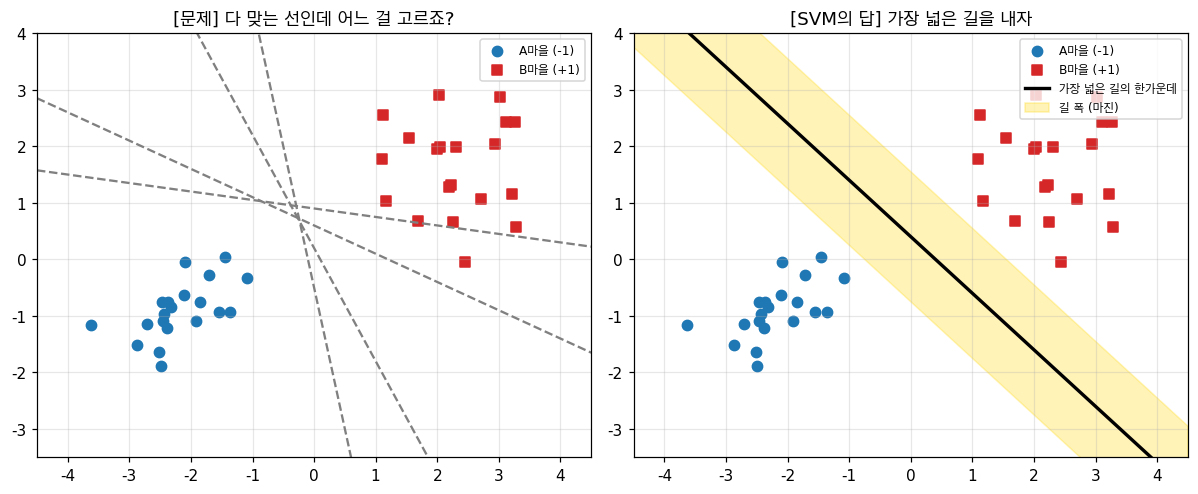

왼쪽 네 선 모두 훈련 데이터를 100% 맞힙니다.
하지만 새 점이 들어오면? 길이 좁은 선일수록 먼저 틀립니다.


In [2]:
# ✨ 추가 — 같은 데이터를 가르는 선 여러 개를 그려 봅니다
def 두무리만들기(시드=0, n=20):
    r = np.random.default_rng(시드)
    A = r.normal([-2.0, -1.0], 0.7, size=(n, 2))    # -1 무리
    B = r.normal([2.0, 1.5], 0.7, size=(n, 2))      # +1 무리
    X = np.vstack([A, B])
    y = np.array([-1] * n + [1] * n)
    return X, y

X0, y0 = 두무리만들기()

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
for a in ax:
    a.scatter(X0[y0 == -1, 0], X0[y0 == -1, 1], c="tab:blue", s=45, label="A마을 (-1)")
    a.scatter(X0[y0 == 1, 0], X0[y0 == 1, 1], c="tab:red", s=45, marker="s", label="B마을 (+1)")
    a.set_xlim(-4.5, 4.5); a.set_ylim(-3.5, 4.0)
    a.grid(alpha=0.3)

# 왼쪽: 아무 선이나 여러 개 (전부 완벽히 가릅니다)
xs = np.linspace(-4.5, 4.5, 50)
for 기울기, 절편, c in [(-0.5, 0.6, "gray"), (-2.0, 0.2, "gray"),
                        (-0.15, 0.9, "gray"), (-5.0, -0.5, "gray")]:
    ax[0].plot(xs, 기울기 * xs + 절편, c=c, lw=1.5, ls="--")
ax[0].set_title("[문제] 다 맞는 선인데 어느 걸 고르죠?")

# 오른쪽: 가장 넓은 길
ax[1].plot(xs, -1.0 * xs + 0.4, c="black", lw=2.2, label="가장 넓은 길의 한가운데")
ax[1].fill_between(xs, -1.0 * xs + 0.4 - 1.15, -1.0 * xs + 0.4 + 1.15,
                   color="gold", alpha=0.28, label="길 폭 (마진)")
ax[1].set_title("[SVM의 답] 가장 넓은 길을 내자")
ax[1].legend(fontsize=8, loc="upper right")
ax[0].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

print("왼쪽 네 선 모두 훈련 데이터를 100% 맞힙니다.")
print("하지만 새 점이 들어오면? 길이 좁은 선일수록 먼저 틀립니다.")

---

## 1️⃣ 🔑 마진 — 길 폭을 재는 법

> 🔗 **앞 절과 이어서** — 0절에서 "가장 넓은 길을 내자"고 정했습니다.
> 그런데 **"넓다"를 어떻게 재죠?** 재지 못하면 최대로 만들 수도 없습니다.
> 먼저 **자**를 만듭니다.

> 📗 **원문** — "The maximum margin classifier"

### 선을 수식으로 쓰면

2차원에서 선 하나는 이렇게 씁니다.

$$w_1 x_1 + w_2 x_2 + b = 0 \quad\Longleftrightarrow\quad \mathbf{w}^\top \mathbf{x} + b = 0$$

여기서 $\mathbf{w}$는 **선에 수직인 화살표**(법선 벡터)이고, $b$는 선을 앞뒤로 밀어 주는 값입니다.

### 점에서 선까지의 거리

> 📗 **원문 수식**

$$\text{거리} = \frac{|\mathbf{w}^\top \mathbf{x}_i + b|}{\|\mathbf{w}\|}$$

**분자**는 "선의 식에 점을 넣었을 때 나오는 값"이고, **분모**는 $\mathbf{w}$의 길이입니다.

> 🧸 왜 나눠 주나요? $\mathbf{w}$와 $b$를 전부 2배 해도 **같은 선**입니다
> ($2x + 2y + 2 = 0$과 $x + y + 1 = 0$은 같은 선이죠).
> 그런데 분자만 보면 값이 2배가 됩니다. 그래서 $\|\mathbf{w}\|$로 나눠 **길이 단위를 통일**합니다.

### 라벨을 +1과 −1로 쓰는 이유

> 📗 **원문** — labels y_i in {-1, +1}

3단원 로지스틱 회귀는 라벨이 0과 1이었습니다. SVM은 **−1과 +1**을 씁니다. 왜냐면

$$y_i (\mathbf{w}^\top \mathbf{x}_i + b) > 0 \iff \text{맞게 분류함}$$

이 한 줄로 정리되기 때문입니다.

- 정답이 +1인데 예측값도 양수 → 곱하면 **양수** ✔
- 정답이 −1인데 예측값도 음수 → 곱하면 **양수** ✔
- 하나라도 어긋나면 → 곱하면 **음수** ✘

이 $y_i(\mathbf{w}^\top\mathbf{x}_i + b)$를 **함수 마진**이라고 부릅니다. 앞으로 계속 나옵니다.

### 최대 마진 문제

> 📗 **원문 수식**

$$\max \ \frac{2}{\|\mathbf{w}\|} \quad \text{s.t.}\quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \ge 1 \ \ \forall i$$

조건식의 **1**은 어디서 왔을까요? $\mathbf{w}, b$를 마음대로 늘리고 줄일 수 있으니,
**"가장 가까운 점에서 함수 마진이 딱 1이 되도록"** 크기를 맞춰 버린 것입니다. 약속일 뿐입니다.

그렇게 약속하면 길 폭이 정확히 $\frac{2}{\|\mathbf{w}\|}$가 됩니다.

**$\|\mathbf{w}\|$가 작을수록 길이 넓습니다.** 그래서 최대화 문제를 최소화 문제로 뒤집습니다.

$$\min \ \tfrac{1}{2}\|\mathbf{w}\|^2 \quad \text{s.t.}\quad y_i(\mathbf{w}^\top\mathbf{x}_i + b) \ge 1$$

> 제곱과 $\tfrac12$을 붙인 건 **미분하면 깔끔해지기 때문**입니다 (미분하면 그냥 $\mathbf{w}$).
> 이건 **볼록(convex) 이차 계획 문제**라서 **답이 딱 하나**로 정해집니다.
> 경사하강법처럼 "시작점 따라 다른 답"이 나오지 않습니다.

> ✨ **추가** — 손으로 직접 거리와 길 폭을 계산해 봅니다.

In [3]:
# ✨ 추가 — 거리·마진을 직접 계산해 확인합니다
w = np.array([1.0, 1.0])
b = 0.0
print(f"선: {w[0]}*x1 + {w[1]}*x2 + {b} = 0   (즉 x2 = -x1 인 대각선)")
print(f"||w|| = sqrt({w[0]}^2 + {w[1]}^2) = {np.linalg.norm(w):.4f}\n")

점들 = np.array([[1.0, 1.0], [0.0, 0.0], [-2.0, -2.0], [3.0, -1.0]])
print(f"{'점':<14}{'w·x+b':>10}{'거리':>10}   설명")
print("-" * 55)
for p in 점들:
    값 = w @ p + b
    거리 = abs(값) / np.linalg.norm(w)
    설명 = "선 위에 있음" if abs(값) < 1e-9 else ("선의 + 쪽" if 값 > 0 else "선의 - 쪽")
    print(f"{str(p):<14}{값:>10.3f}{거리:>10.3f}   {설명}")

print("\n[크기를 2배 해도 같은 선인지 확인]")
값1 = w @ np.array([1.0, 1.0]) + b
값2 = (2 * w) @ np.array([1.0, 1.0]) + 2 * b
print(f"  w   일 때: w·x+b = {값1:.3f}, 거리 = {abs(값1)/np.linalg.norm(w):.4f}")
print(f"  2w  일 때: w·x+b = {값2:.3f}, 거리 = {abs(값2)/np.linalg.norm(2*w):.4f}")
print("  => w·x+b 값은 2배가 됐지만 거리는 똑같습니다. 그래서 ||w||로 나눠야 합니다.")

선: 1.0*x1 + 1.0*x2 + 0.0 = 0   (즉 x2 = -x1 인 대각선)
||w|| = sqrt(1.0^2 + 1.0^2) = 1.4142

점                  w·x+b        거리   설명
-------------------------------------------------------
[1. 1.]            2.000     1.414   선의 + 쪽
[0. 0.]            0.000     0.000   선 위에 있음
[-2. -2.]         -4.000     2.828   선의 - 쪽
[ 3. -1.]          2.000     1.414   선의 + 쪽

[크기를 2배 해도 같은 선인지 확인]
  w   일 때: w·x+b = 2.000, 거리 = 1.4142
  2w  일 때: w·x+b = 4.000, 거리 = 1.4142
  => w·x+b 값은 2배가 됐지만 거리는 똑같습니다. 그래서 ||w||로 나눠야 합니다.


In [4]:
# ✨ 추가 — '함수 마진을 1로 맞추면 길 폭이 2/||w||'를 확인합니다
X1, y1 = 두무리만들기(시드=1, n=15)

# 두 무리를 전부 맞게 가르는 '방향이 서로 다른' 선 세 개
후보들 = [("선 A", np.array([1.0, 0.6]), -0.4),
          ("선 B", np.array([1.0, 0.2]), -0.6),
          ("선 C", np.array([0.4, 1.0]), -0.3)]

print(f"{'선':<7}{'||w||':>9}{'2/||w||':>11}{'직접 잰 폭':>13}{'다 맞혔나':>11}")
print("-" * 52)
눈대중최고 = 0.0
for 이름, w_, b_ in 후보들:
    함수마진 = y1 * (X1 @ w_ + b_)
    다맞힘 = np.all(함수마진 > 0)
    # 크기를 조절해 '가장 가까운 점의 함수 마진 = 1'로 맞춥니다
    배율 = 1.0 / 함수마진.min()
    w정규, b정규 = w_ * 배율, b_ * 배율
    폭 = 2 / np.linalg.norm(w정규)
    눈대중최고 = max(눈대중최고, 폭)
    실제폭 = 2 * (np.abs(X1 @ w정규 + b정규) / np.linalg.norm(w정규)).min()
    print(f"{이름:<7}{np.linalg.norm(w정규):>9.3f}{폭:>11.3f}{실제폭:>13.3f}"
          f"{('예' if 다맞힘 else '아니오'):>11}")

print("\n=> ① 2/||w|| 열과 '직접 잰 폭' 열이 정확히 같습니다.")
print("      '가장 가까운 점의 함수 마진 = 1'로 크기를 맞췄기 때문입니다.")
print("   ② 세 선 다 훈련 데이터를 100% 맞히는데 길 폭은 제각각입니다.")
print("      ||w||가 가장 작은 선 A가 길이 가장 넓습니다. 그래서 ||w||를 줄이는 게 목표입니다.")

선          ||w||    2/||w||       직접 잰 폭      다 맞혔나
----------------------------------------------------
선 A        0.861      2.322        2.322          예
선 B        1.368      1.461        1.461          예
선 C        1.533      1.304        1.304          예

=> ① 2/||w|| 열과 '직접 잰 폭' 열이 정확히 같습니다.
      '가장 가까운 점의 함수 마진 = 1'로 크기를 맞췄기 때문입니다.
   ② 세 선 다 훈련 데이터를 100% 맞히는데 길 폭은 제각각입니다.
      ||w||가 가장 작은 선 A가 길이 가장 넓습니다. 그래서 ||w||를 줄이는 게 목표입니다.


In [5]:
# ✨ 추가 — 그럼 진짜 최댓값은 얼마일까요? SVM에게 물어봅니다
from sklearn.svm import SVC

최적 = SVC(kernel="linear", C=1e6).fit(X1, y1)      # C를 크게 = 하드 마진
print(f"내가 눈대중으로 고른 최고    : 길 폭 {눈대중최고:.3f}")
print(f"SVM이 찾아낸 최댓값          : 길 폭 {2/np.linalg.norm(최적.coef_[0]):.3f}")
print(f"\n=> SVM은 '가능한 모든 선 중에서' 이 값을 최대로 만드는 선을 찾아 줍니다.")
print("   그것도 답이 딱 하나로 정해지는 볼록 문제라서, 매번 같은 답이 나옵니다.")

내가 눈대중으로 고른 최고    : 길 폭 2.322
SVM이 찾아낸 최댓값          : 길 폭 2.594

=> SVM은 '가능한 모든 선 중에서' 이 값을 최대로 만드는 선을 찾아 줍니다.
   그것도 답이 딱 하나로 정해지는 볼록 문제라서, 매번 같은 답이 나옵니다.


---

## 2️⃣ 서포트 벡터 — 소수의 결정권자

> 🔗 **앞 절과 이어서** — 1절에서 길 폭을 최대로 벌렸습니다.
> 그러고 나면 **딱 길가에 걸린 점 몇 개**가 생깁니다. 이 점들이 경계를 정합니다.
> **왜 나머지는 아무 영향이 없을까요?** 이 질문의 답은 4절에 있습니다. 일단 사실부터 확인합니다.

> 📗 **원문** — "Support vectors: the critical few"

길 폭을 최대로 벌리고 나면, **딱 길가에 걸쳐 있는 점 몇 개**가 생깁니다.
$y_i(\mathbf{w}^\top\mathbf{x}_i + b) = 1$ 인 점들이죠. 이 점들을 **서포트 벡터**라고 부릅니다.

### 🧸 비유 — 담장을 미는 사람들

담장을 최대한 넓게 벌리려고 양쪽에서 밀고 있다고 생각해 보세요.
**담장에 손이 닿은 사람만** 담장 위치를 정합니다.
마을 안쪽 깊숙이 있는 사람들은 아무리 많아도 **담장을 1mm도 못 움직입니다.**

> 📗 **원문**: "Move or remove any non-support-vector point, and the boundary does not change."
> (서포트 벡터가 아닌 점은 옮기든 지우든 경계가 안 바뀝니다.)

### 그래서 좋은 점

- **예측할 때 서포트 벡터만 저장하면 됩니다.** 훈련 데이터 10만 개 중 서포트 벡터가 200개면, 200개만 들고 있으면 돼요.
- **서포트 벡터가 적을수록 일반화가 잘 됩니다.** 소수만으로 결정되는 경계일수록 데이터가 조금 바뀌어도 흔들리지 않으니까요.

> ✨ **추가** — '서포트 벡터가 아닌 점은 지워도 똑같다'를 직접 확인합니다. (sklearn을 잠깐 빌립니다. 5절에서 직접 만듭니다.)

In [6]:
# ✨ 추가 — 서포트 벡터가 아닌 점을 다 지워도 경계가 같은지 봅니다
X2, y2 = 두무리만들기(시드=3, n=25)

전체모델 = SVC(kernel="linear", C=1000).fit(X2, y2)   # C가 크면 거의 하드 마진
서포트번호 = 전체모델.support_
print(f"전체 점 {len(X2)}개 중 서포트 벡터는 {len(서포트번호)}개입니다: {서포트번호}")

# 서포트 벡터만 남기고 다시 학습
소수모델 = SVC(kernel="linear", C=1000).fit(X2[서포트번호], y2[서포트번호])

print(f"\n{'':<14}{'w':>22}{'b':>10}")
print("-" * 48)
print(f"{'전체로 학습':<12}{str(np.round(전체모델.coef_[0], 4)):>24}{전체모델.intercept_[0]:>10.4f}")
print(f"{'서포트만 학습':<11}{str(np.round(소수모델.coef_[0], 4)):>24}{소수모델.intercept_[0]:>10.4f}")

차이 = np.abs(전체모델.coef_[0] - 소수모델.coef_[0]).max()
print(f"\n=> w의 최대 차이: {차이:.2e}  (사실상 0)")
print(f"   점 {len(X2)}개 중 {len(X2)-len(서포트번호)}개를 버렸는데 경계가 그대로입니다.")

전체 점 50개 중 서포트 벡터는 2개입니다: [23 32]

                                   w         b
------------------------------------------------
전체로 학습                 [0.737 0.619]    0.0436
서포트만 학습               [0.737 0.619]    0.0436

=> w의 최대 차이: 3.75e-09  (사실상 0)
   점 50개 중 48개를 버렸는데 경계가 그대로입니다.


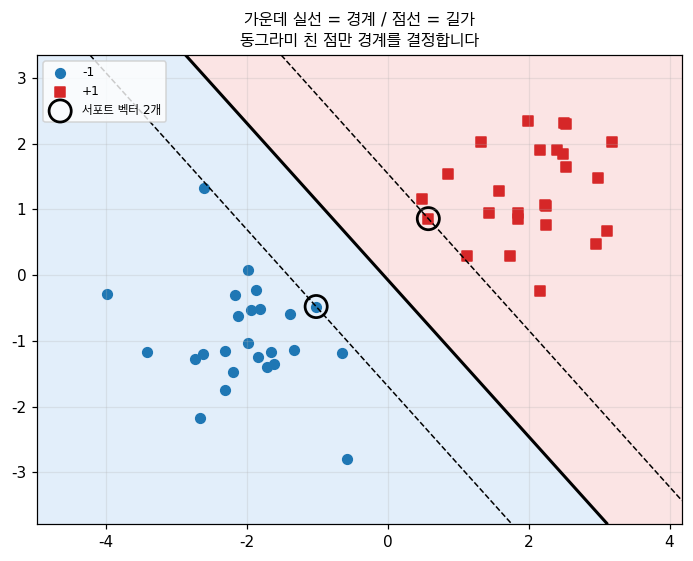

길 폭 = 2/||w|| = 2.079
점선 두 개 사이 거리가 바로 이 값입니다.


In [7]:
# ✨ 추가 — 마진과 서포트 벡터를 그림으로 봅니다
def 경계그리기(ax, 모델, X, y, 제목, 마진선=True):
    x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300)
    x2 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
    G1, G2 = np.meshgrid(x1, x2)
    Z = 모델.decision_function(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
    ax.contourf(G1, G2, Z, levels=[-1e9, 0, 1e9], colors=["#cfe3f7", "#f9d3d3"], alpha=0.6)
    수준 = [-1, 0, 1] if 마진선 else [0]
    스타일 = ["--", "-", "--"] if 마진선 else ["-"]
    ax.contour(G1, G2, Z, levels=수준, colors="k", linestyles=스타일, linewidths=[1, 2, 1][:len(수준)])
    ax.scatter(X[y == -1, 0], X[y == -1, 1], c="tab:blue", s=40, label="-1")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="tab:red", s=40, marker="s", label="+1")
    sv = X[모델.support_]
    ax.scatter(sv[:, 0], sv[:, 1], s=210, facecolors="none", edgecolors="black",
               linewidths=1.8, label=f"서포트 벡터 {len(sv)}개")
    ax.set_title(제목, fontsize=11)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)

fig, ax = plt.subplots(figsize=(6.4, 5.2))
경계그리기(ax, 전체모델, X2, y2, "가운데 실선 = 경계 / 점선 = 길가\n동그라미 친 점만 경계를 결정합니다")
plt.tight_layout(); plt.show()

폭 = 2 / np.linalg.norm(전체모델.coef_[0])
print(f"길 폭 = 2/||w|| = {폭:.3f}")
print("점선 두 개 사이 거리가 바로 이 값입니다.")

---

## 3️⃣ 소프트 마진과 C — 실수를 봐주기

> 🔗 **여기서 현실을 만납니다** — 1·2절은 **두 무리가 깨끗하게 갈린다**는 가정 위에 있었습니다.
> 반대편에 넘어간 점이 **하나만 있어도** 1절의 조건은 만족시킬 수가 없습니다. 답이 아예 없어요.
> 그래서 조건을 느슨하게 풀어 줍니다.

> 📗 **원문** — "Soft margin: handling noise with the C parameter"

지금까지는 **두 무리가 깨끗하게 갈리는** 경우만 봤습니다. 그런데 실제 데이터는 섞여 있습니다.
반대편에 넘어가 있는 점이 하나라도 있으면, "모든 점이 $y_i f(x_i) \ge 1$" 조건은 **아예 답이 없습니다.**

그래서 조건을 느슨하게 풉니다. **슬랙 변수** $\xi_i$ ("봐준 만큼")를 도입해요.

$$\min \ \tfrac12\|\mathbf{w}\|^2 + C\sum_i \xi_i \quad\text{s.t.}\quad y_i(\mathbf{w}^\top\mathbf{x}_i+b) \ge 1 - \xi_i,\ \ \xi_i \ge 0$$

### 🧸 비유 — 담장에 문을 내주기

담장을 세우는데 어떤 집은 애매하게 담장 위에 걸쳐 있습니다. 두 가지 선택이 있어요.

- **"한 명도 예외 없다"** → 담장이 이상하게 구불구불해집니다. (좁은 길, 과적합)
- **"몇 명은 봐주자"** → 담장이 깔끔해집니다. (넓은 길, 실수는 조금)

$C$가 바로 **"봐주는 값이 얼마나 비싼가"**입니다.

> 📗 **원문 표**

| C 값 | 무슨 일이 벌어지나 |
| --- | --- |
| **큰 C** | 실수 하나가 비쌉니다 → 길이 좁아짐, 훈련 실수 적음 → **과적합** |
| **작은 C** | 실수를 봐줍니다 → 길이 넓어짐, 훈련 실수 많음 → **과소적합** |

> ⚠️ **헷갈리기 쉬운 점**: C는 규제 강도의 **반대**입니다.
> **C가 크면 규제가 약합니다** (2단원 릿지의 $\lambda$와 반대 방향이에요).

> ✨ **추가** — C를 바꿔 가며 길 폭·실수 개수·테스트 정확도가 어떻게 움직이는지 직접 잽니다.

In [8]:
# ✨ 추가 — C를 바꾸면 실제로 뭐가 바뀌는지 숫자로 봅니다
def 섞인데이터(시드=0, n=200):
    r = np.random.default_rng(시드)
    A = r.normal([-1.1, -0.6], 1.1, size=(n // 2, 2))
    B = r.normal([1.1, 0.8], 1.1, size=(n // 2, 2))
    X = np.vstack([A, B])
    y = np.array([-1] * (n // 2) + [1] * (n // 2))
    p = r.permutation(len(X))
    return X[p], y[p]

X3, y3 = 섞인데이터(0, 200)
X3te, y3te = 섞인데이터(1, 400)

print(f"{'C':>8}{'길 폭':>10}{'서포트 벡터':>13}{'훈련 실수':>11}{'훈련 정확도':>13}{'테스트 정확도':>14}")
print("-" * 70)
C결과 = []
for C in [0.001, 0.01, 0.1, 1, 10, 100, 1000]:
    m = SVC(kernel="linear", C=C).fit(X3, y3)
    폭 = 2 / np.linalg.norm(m.coef_[0])
    훈련 = m.score(X3, y3)
    테스트 = m.score(X3te, y3te)
    C결과.append((C, 폭, len(m.support_), 훈련, 테스트))
    print(f"{C:>8}{폭:>10.3f}{len(m.support_):>13}{int(round((1-훈련)*len(X3))):>11}"
          f"{훈련:>13.1%}{테스트:>14.1%}")

print("\n=> C가 커질수록 길 폭이 좁아지고 서포트 벡터가 줄어듭니다. 원문 표 그대로입니다.")
최고 = max(C결과, key=lambda r: r[4])
print(f"   이 데이터에서 테스트가 가장 좋은 C는 {최고[0]} 였습니다 ({최고[4]:.1%}).")

       C       길 폭       서포트 벡터      훈련 실수       훈련 정확도       테스트 정확도
----------------------------------------------------------------------
   0.001     8.375          200         29        85.5%         87.5%
    0.01     3.110          122         24        88.0%         90.0%
     0.1     1.786           78         22        89.0%         89.8%
       1     1.393           66         24        88.0%         89.8%
      10     1.386           65         24        88.0%         89.8%
     100     1.386           65         24        88.0%         89.8%
    1000     1.386           65         24        88.0%         89.8%

=> C가 커질수록 길 폭이 좁아지고 서포트 벡터가 줄어듭니다. 원문 표 그대로입니다.
   이 데이터에서 테스트가 가장 좋은 C는 0.01 였습니다 (90.0%).


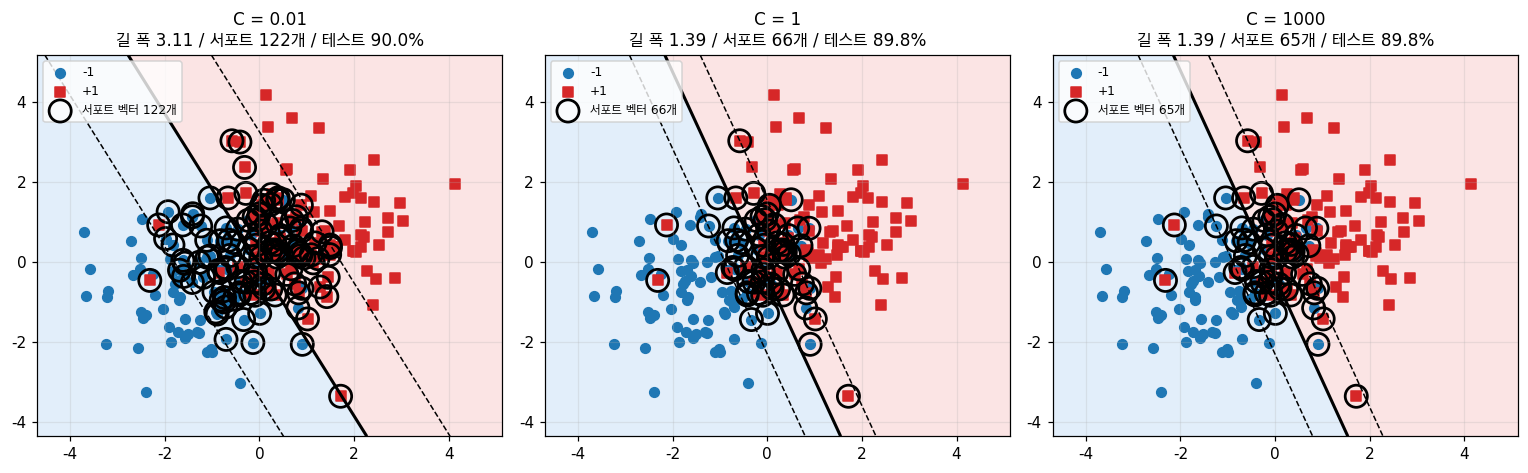

왼쪽(C 작음): 길이 넓고 안쪽에 점이 잔뜩 들어와 있습니다. 대충 넘어가는 중입니다.
오른쪽(C 큼): 길이 좁습니다. 점 하나하나를 다 신경 쓰다가 이렇게 됐습니다.


In [9]:
# ✨ 추가 — C가 작을 때 / 클 때 경계를 나란히 그립니다
fig, ax = plt.subplots(1, 3, figsize=(14, 4.4))
for a, C in zip(ax, [0.01, 1, 1000]):
    m = SVC(kernel="linear", C=C).fit(X3, y3)
    경계그리기(a, m, X3, y3, f"C = {C}\n길 폭 {2/np.linalg.norm(m.coef_[0]):.2f} / "
                            f"서포트 {len(m.support_)}개 / 테스트 {m.score(X3te, y3te):.1%}")
plt.tight_layout(); plt.show()

print("왼쪽(C 작음): 길이 넓고 안쪽에 점이 잔뜩 들어와 있습니다. 대충 넘어가는 중입니다.")
print("오른쪽(C 큼): 길이 좁습니다. 점 하나하나를 다 신경 쓰다가 이렇게 됐습니다.")

---

## 4️⃣ 🔑 힌지 손실

> 🔗 **⭐ 이 단원에서 가장 중요한 연결입니다** — "갑자기 왜 손실 함수?" 싶으실 텐데,
> **3절에서 도입한 슬랙 $\xi_i$를 식으로 풀어 쓴 것이 바로 힌지 손실입니다.**
> 새로운 개념이 아니라 **같은 것의 다른 표현**이에요.
>
> 그리고 이 절이 **2절의 남은 숙제**도 풀어 줍니다.
> "왜 서포트 벡터가 아닌 점은 지워도 되는가?" → **힌지 손실이 정확히 0이기 때문입니다.**

> 📗 **원문** — "Hinge loss: the SVM loss function"

3절의 제약 조건 문제는 사실 **제약 없는 한 줄**로 바꿀 수 있습니다.

$$\min \ \tfrac12\|\mathbf{w}\|^2 + C\sum_i \max\bigl(0,\ 1 - y_i(\mathbf{w}^\top\mathbf{x}_i+b)\bigr)$$

이 $\max(0,\ 1 - y f(x))$가 **힌지 손실(hinge loss)**입니다.

### 🧸 왜 '힌지(경첩)'인가요?

그래프를 그려 보면 **경첩(문 돌쩌귀)처럼 한 점에서 딱 꺾입니다.**

```
손실
  |\
  | \
  |  \
  |   \
  |    \________________
  +-----+------+--------->  y·f(x)
        0      1
```

- $y f(x) \ge 1$ → **손실 0**. "맞혔고, 길 밖에 충분히 나가 있음. 더 볼 일 없음"
- $y f(x) < 1$ → **직선으로 벌점**. 길 안에 들어와 있거나 아예 틀렸음

### 🔑 로지스틱 손실과 뭐가 다른가요?

> 📗 **원문 비교**

| | 힌지 (SVM) | 로지스틱 (3단원) |
| --- | --- | --- |
| 식 | $\max(0, 1-yf)$ | $\log(1+e^{-yf})$ |
| 잘 맞힌 점 | **손실 정확히 0** | 아주 작지만 **0은 아님** |
| 쓰는 점 | 길가 근처 몇 개 | **전부** |
| 결과 | **희소함** (서포트 벡터만 남음) | 조밀함 |

**"정확히 0"이라는 게 핵심입니다.** 손실이 0이면 그 점은 기울기에 아무 기여도 안 합니다.
그래서 그 점을 지워도 답이 안 바뀌고, 결국 **서포트 벡터만 남는 것**입니다.

> 2절에서 "서포트 벡터가 아닌 점은 지워도 똑같다"고 했죠? 그 이유가 바로 여기 있습니다.

> ✨ **추가** — 두 손실을 나란히 그리고, 값도 직접 찍어 봅니다.

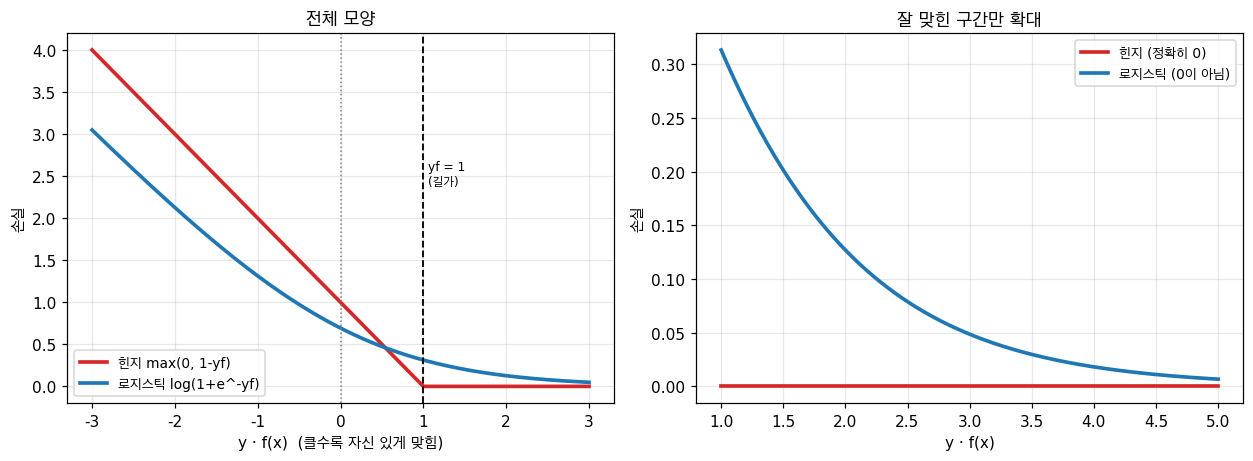

   y·f(x)          힌지          로지스틱   해석
--------------------------------------------------------------
     -2.0    3.000000      2.126928   틀림
      0.0    1.000000      0.693147   길 안에 있음
      0.5    0.500000      0.474077   길 안에 있음
      1.0    0.000000      0.313262   길 밖, 안전
      2.0    0.000000      0.126928   길 밖, 안전
      5.0    0.000000      0.006715   길 밖, 안전
     10.0    0.000000      0.000045   길 밖, 안전

=> y·f(x)=5 일 때 힌지는 정확히 0인데, 로지스틱은 0.0067로 아직 살아 있습니다.
   로지스틱은 '이미 잘 맞힌 점'도 계속 조금씩 경계를 당깁니다. 힌지는 손을 뗍니다.


In [10]:
# ✨ 추가 — 힌지 손실 vs 로지스틱 손실
def 힌지(yf):
    return np.maximum(0.0, 1.0 - yf)

def 로지스틱(yf):
    return np.log1p(np.exp(-yf))

t = np.linspace(-3, 3, 400)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))
ax[0].plot(t, 힌지(t), lw=2.4, c="tab:red", label="힌지 max(0, 1-yf)")
ax[0].plot(t, 로지스틱(t), lw=2.4, c="tab:blue", label="로지스틱 log(1+e^-yf)")
ax[0].axvline(0, c="gray", lw=1, ls=":")
ax[0].axvline(1, c="black", lw=1.2, ls="--")
ax[0].text(1.05, 2.4, "yf = 1\n(길가)", fontsize=8)
ax[0].set_xlabel("y · f(x)  (클수록 자신 있게 맞힘)")
ax[0].set_ylabel("손실"); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)
ax[0].set_title("전체 모양")

# 오른쪽: 잘 맞힌 구간 확대
t2 = np.linspace(1, 5, 300)
ax[1].plot(t2, 힌지(t2), lw=2.4, c="tab:red", label="힌지 (정확히 0)")
ax[1].plot(t2, 로지스틱(t2), lw=2.4, c="tab:blue", label="로지스틱 (0이 아님)")
ax[1].set_xlabel("y · f(x)"); ax[1].set_ylabel("손실")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
ax[1].set_title("잘 맞힌 구간만 확대")
plt.tight_layout(); plt.show()

print(f"{'y·f(x)':>9}{'힌지':>12}{'로지스틱':>14}   해석")
print("-" * 62)
for v in [-2.0, 0.0, 0.5, 1.0, 2.0, 5.0, 10.0]:
    설명 = "틀림" if v < 0 else ("길 안에 있음" if v < 1 else "길 밖, 안전")
    print(f"{v:>9.1f}{힌지(np.array([v]))[0]:>12.6f}{로지스틱(np.array([v]))[0]:>14.6f}   {설명}")

print("\n=> y·f(x)=5 일 때 힌지는 정확히 0인데, 로지스틱은 0.0067로 아직 살아 있습니다.")
print("   로지스틱은 '이미 잘 맞힌 점'도 계속 조금씩 경계를 당깁니다. 힌지는 손을 뗍니다.")

---

## 5️⃣ 🔨 선형 SVM을 밑바닥부터

> 🔗 **앞 절과 이어서** — 4절 덕분에 문제가 **제약 조건 없는 한 줄**이 됐습니다.
> 제약이 없으면? **2단원에서 만든 경사하강법을 그대로 쓸 수 있습니다.**
> 바뀐 건 손실 함수 하나뿐이에요 (MSE → 힌지).

> 📗 **원문** — "Training a linear SVM with gradient descent" + "Build It: Step 1, 2"

이제 직접 만듭니다. 목표 함수는 이렇게 씁니다 (원문 형태).

$$L(\mathbf{w}, b) = \frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{n}\sum_i \max\bigl(0, 1 - y_i(\mathbf{w}^\top\mathbf{x}_i+b)\bigr)$$

### 기울기는 '경우 나누기'입니다

> 📗 **원문 수식**

$$\frac{\partial L}{\partial \mathbf{w}} = \begin{cases} \lambda \mathbf{w} & y_i f(x_i) \ge 1 \ \text{(잘 맞힘)} \\ \lambda\mathbf{w} - y_i \mathbf{x}_i & y_i f(x_i) < 1 \ \text{(길 안 또는 틀림)}\end{cases}$$

$$\frac{\partial L}{\partial b} = \begin{cases} 0 & y_i f(x_i) \ge 1 \\ -y_i & y_i f(x_i) < 1\end{cases}$$

### 🧸 이걸 말로 풀면

- **잘 맞힌 점**: "너는 됐어." → $\mathbf{w}$를 살짝 줄이기만 합니다 (규제).
  $\mathbf{w}$를 줄이면 $2/\|\mathbf{w}\|$가 커지니까 **길이 넓어집니다.**
- **길 안에 있거나 틀린 점**: "너 때문에 안 되겠다." → 그 점 쪽으로 $\mathbf{w}$를 **당깁니다** ($-y_i\mathbf{x}_i$).

> 🔎 힌지 손실은 $yf=1$ 에서 꺾여서 **미분이 안 됩니다.** 정확히는 이걸
> **열劣기울기(subgradient)**라고 부르는데, 꺾인 점에서 그냥 한쪽 값을 골라 쓰는 겁니다. 잘 동작합니다.

### 왜 스케일링이 중요한가

$\|\mathbf{w}\|$가 목표에 직접 들어가기 때문에, **특징의 단위가 다르면 기하가 왜곡됩니다.**
2단원에서 배운 표준화를 **SVM에서는 선택이 아니라 필수**로 생각하세요. 아래에서 확인합니다.

In [11]:
# 📗 원문 Step 1 — 힌지 손실 (원문은 for 문, 여기서는 넘파이로 한 번에)
def 힌지손실(X, y, w, b):
    함수마진 = y * (X @ w + b)
    return np.mean(np.maximum(0.0, 1.0 - 함수마진))

# 확인: 아주 잘 맞히는 w와, 반대로 뒤집힌 w
Xc, yc = 두무리만들기(시드=0, n=20)
좋은w, 좋은b = np.array([0.9, 0.5]), 0.0
print(f"괜찮은 w={좋은w}   힌지손실 = {힌지손실(Xc, yc, 좋은w, 좋은b):.4f}")
print(f"뒤집힌 w={-좋은w}  힌지손실 = {힌지손실(Xc, yc, -좋은w, 좋은b):.4f}")
print(f"w=0 (아무것도 모름)   힌지손실 = {힌지손실(Xc, yc, np.zeros(2), 0.0):.4f}")
print("\n=> w=0이면 모든 점의 y·f(x)=0 이므로 손실이 정확히 1.0입니다. 이게 '찍기' 기준선입니다.")

괜찮은 w=[0.9 0.5]   힌지손실 = 0.0000
뒤집힌 w=[-0.9 -0.5]  힌지손실 = 3.6457
w=0 (아무것도 모름)   힌지손실 = 1.0000

=> w=0이면 모든 점의 y·f(x)=0 이므로 손실이 정확히 1.0입니다. 이게 '찍기' 기준선입니다.


In [12]:
# 📗 원문 Step 2 — 선형 SVM (원문은 점 하나씩, 여기서는 전체 배치로 + 손실 기록)
class 선형SVM:
    def __init__(self, 학습률=0.01, 람다=0.01, 반복=1000):
        self.학습률 = 학습률
        self.람다 = 람다        # 규제 세기 (C와 반대 방향입니다)
        self.반복 = 반복
        self.w = None
        self.b = 0.0
        self.손실기록 = []

    def 결정값(self, X):
        # w·x + b. 부호가 예측, 크기가 '얼마나 확신하는가'
        return X @ self.w + self.b

    def 목표값(self, X, y):
        return 0.5 * self.람다 * (self.w @ self.w) + 힌지손실(X, y, self.w, self.b)

    def 학습(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        self.손실기록 = []
        for _ in range(self.반복):
            함수마진 = y * self.결정값(X)
            위반 = 함수마진 < 1              # 길 안에 있거나 틀린 점들
            # 규제 항은 항상, 당기는 항은 위반한 점에서만
            dw = self.람다 * self.w - (X[위반].T @ y[위반]) / n
            db = -y[위반].sum() / n
            self.w -= self.학습률 * dw
            self.b -= self.학습률 * db
            self.손실기록.append(self.목표값(X, y))
        return self

    def 예측(self, X):
        return np.where(self.결정값(X) >= 0, 1, -1)

    def 점수(self, X, y):
        return np.mean(self.예측(X) == y)

print("클래스 준비 완료")

클래스 준비 완료


In [13]:
# 만든 SVM을 학습시켜 봅니다
X5, y5 = 섞인데이터(0, 200)
X5te, y5te = 섞인데이터(1, 400)

내SVM = 선형SVM(학습률=0.05, 람다=0.01, 반복=800).학습(X5, y5)
print(f"내 SVM    w={np.round(내SVM.w,4)}  b={내SVM.b:+.4f}  "
      f"훈련 {내SVM.점수(X5,y5):.1%}  테스트 {내SVM.점수(X5te,y5te):.1%}")

# sklearn과 비교 (같은 목표를 푸는 게 맞는지 확인)
비교모델 = SVC(kernel="linear", C=1.0/(0.01*len(X5))).fit(X5, y5)
print(f"sklearn   w={np.round(비교모델.coef_[0],4)}  b={비교모델.intercept_[0]:+.4f}  "
      f"훈련 {비교모델.score(X5,y5):.1%}  테스트 {비교모델.score(X5te,y5te):.1%}")

# 방향(각도)이 얼마나 비슷한지
코사인 = (내SVM.w @ 비교모델.coef_[0]) / (np.linalg.norm(내SVM.w) * np.linalg.norm(비교모델.coef_[0]))
print(f"\n두 w의 방향 일치도(코사인) = {코사인:.4f}  (1에 가까울수록 같은 방향)")
print("크기는 다를 수 있습니다. 방향이 같으면 같은 선입니다.")

내 SVM    w=[1.302 0.52 ]  b=+0.1798  훈련 88.5%  테스트 90.0%
sklearn   w=[1.319 0.519]  b=+0.1879  훈련 88.0%  테스트 90.0%

두 w의 방향 일치도(코사인) = 1.0000  (1에 가까울수록 같은 방향)
크기는 다를 수 있습니다. 방향이 같으면 같은 선입니다.


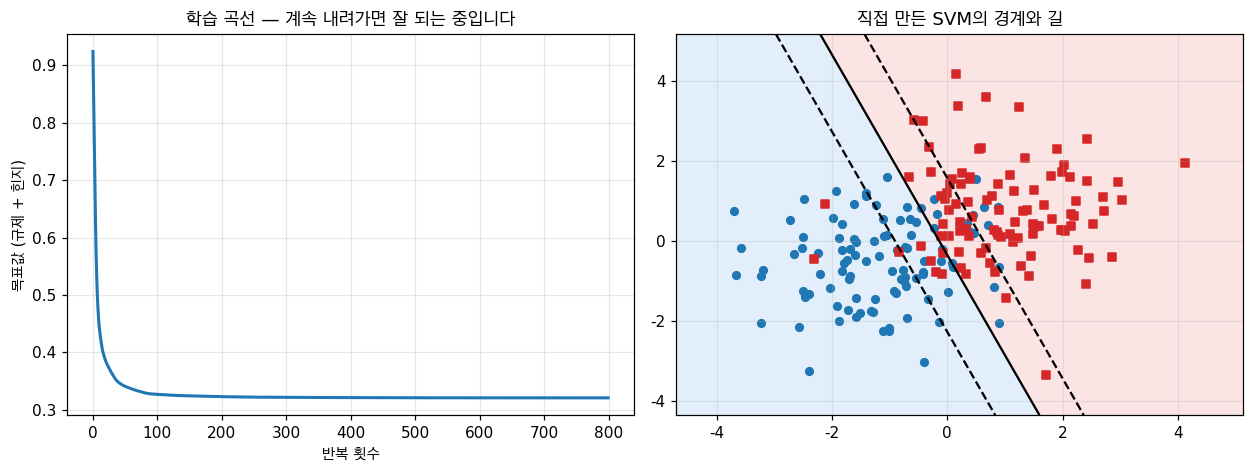

처음 목표값 0.9238 -> 마지막 0.3209
마지막 100번 동안 줄어든 양: 0.000035  (거의 다 수렴했습니다)


In [14]:
# ✨ 추가 — 학습 곡선과 최종 경계
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax[0].plot(내SVM.손실기록, lw=2)
ax[0].set_xlabel("반복 횟수"); ax[0].set_ylabel("목표값 (규제 + 힌지)")
ax[0].set_title("학습 곡선 — 계속 내려가면 잘 되는 중입니다")
ax[0].grid(alpha=0.3)

x1 = np.linspace(X5[:, 0].min()-1, X5[:, 0].max()+1, 300)
x2 = np.linspace(X5[:, 1].min()-1, X5[:, 1].max()+1, 300)
G1, G2 = np.meshgrid(x1, x2)
Z = 내SVM.결정값(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
ax[1].contourf(G1, G2, Z, levels=[-1e9, 0, 1e9], colors=["#cfe3f7", "#f9d3d3"], alpha=0.6)
ax[1].contour(G1, G2, Z, levels=[-1, 0, 1], colors="k", linestyles=["--", "-", "--"])
ax[1].scatter(X5[y5==-1,0], X5[y5==-1,1], c="tab:blue", s=25)
ax[1].scatter(X5[y5==1,0], X5[y5==1,1], c="tab:red", s=25, marker="s")
ax[1].set_title("직접 만든 SVM의 경계와 길")
ax[1].grid(alpha=0.25)
plt.tight_layout(); plt.show()

print(f"처음 목표값 {내SVM.손실기록[0]:.4f} -> 마지막 {내SVM.손실기록[-1]:.4f}")
print(f"마지막 100번 동안 줄어든 양: {내SVM.손실기록[-100]-내SVM.손실기록[-1]:.6f}  (거의 다 수렴했습니다)")

> ✨ **추가** — 원문이 강조한 '스케일링 필수'를 숫자로 확인합니다.

In [15]:
# ✨ 추가 — 스케일이 다르면 SVM이 얼마나 망가지는지
X망 = X5.copy()
X망[:, 1] = X망[:, 1] * 500        # 두 번째 특징만 단위를 500배로 (예: m -> mm)
X망te = X5te.copy()
X망te[:, 1] = X망te[:, 1] * 500

안한거 = 선형SVM(학습률=0.05, 람다=0.01, 반복=800).학습(X망, y5)

평균, 표준 = X망.mean(axis=0), X망.std(axis=0)
한거 = 선형SVM(학습률=0.05, 람다=0.01, 반복=800).학습((X망-평균)/표준, y5)

print(f"{'':<22}{'훈련':>10}{'테스트':>10}")
print("-" * 44)
print(f"{'스케일링 안 함':<20}{안한거.점수(X망,y5):>10.1%}{안한거.점수(X망te,y5te):>10.1%}")
print(f"{'스케일링 함':<21}{한거.점수((X망-평균)/표준,y5):>10.1%}"
      f"{한거.점수((X망te-평균)/표준,y5te):>10.1%}")
print(f"\n스케일링 안 한 쪽 w = {np.round(안한거.w,5)}")
print(f"스케일링 한 쪽   w = {np.round(한거.w,5)}")
print("\n=> 단위만 바꿨을 뿐인데 성능이 무너집니다.")
print("   ||w||를 최소화하는 게 목표라서, 값이 큰 특징 쪽 w는 아주 작게 눌립니다.")
print("   원문도 'always scale your features before training an SVM'이라고 못 박습니다.")

                              훈련       테스트
--------------------------------------------
스케일링 안 함                 71.0%     75.0%
스케일링 함                    89.5%     90.2%

스케일링 안 한 쪽 w = [11.473 10.37 ]
스케일링 한 쪽   w = [1.738 0.656]

=> 단위만 바꿨을 뿐인데 성능이 무너집니다.
   ||w||를 최소화하는 게 목표라서, 값이 큰 특징 쪽 w는 아주 작게 눌립니다.
   원문도 'always scale your features before training an SVM'이라고 못 박습니다.


---

## 6️⃣ 🔨 서포트 벡터 찾기 · 마진 폭 재기

> 🔗 **앞 절과 이어서** — 5절에서 학습이 끝났습니다.
> 이제 **2절에서 개념으로만 이야기했던 서포트 벡터**를, 우리가 만든 모델에서 실제로 찾아냅니다.

> 📗 **원문** — "Build It: Step 4"

학습이 끝나면 **누가 서포트 벡터인지** 알아낼 수 있습니다. 함수 마진이 1 근처인 점들이죠.

```python
def find_support_vectors(X, y, w, b, tol=1e-3):
    ...  if abs(margin - 1.0) < tol:  ...
```

> ⚠️ 원문 코드는 `|마진 − 1| < 톨러런스`로 딱 길가에 있는 점만 찾습니다.
> 하지만 **소프트 마진**에서는 길 **안쪽**으로 들어온 점($yf < 1$)도 손실에 기여하므로 서포트 벡터입니다.
> 그래서 아래에서는 두 가지를 다 세어 보겠습니다.

In [16]:
# 📗 원문 Step 4 — 서포트 벡터 찾기 (+ ✨ 소프트 마진 버전도 같이)
def 서포트벡터찾기(X, y, w, b, 오차=1e-3):
    # 원문 방식: 딱 길가(함수 마진 = 1)에 있는 점
    함수마진 = y * (X @ w + b)
    return np.where(np.abs(함수마진 - 1.0) < 오차)[0]

def 손실에기여하는점(X, y, w, b):
    # ✨ 소프트 마진 실제 서포트 벡터: 길 안에 들어왔거나 틀린 점
    함수마진 = y * (X @ w + b)
    return np.where(함수마진 <= 1.0 + 1e-9)[0]

def 마진폭(w):
    return 2.0 / np.linalg.norm(w)

함수마진들 = y5 * 내SVM.결정값(X5)
딱길가 = 서포트벡터찾기(X5, y5, 내SVM.w, 내SVM.b, 오차=0.02)
기여점 = 손실에기여하는점(X5, y5, 내SVM.w, 내SVM.b)

print(f"전체 점: {len(X5)}개")
print(f"  길 밖에 안전하게 있는 점 (y·f > 1) : {int((함수마진들 > 1).sum())}개  <- 손실 0, 지워도 됨")
print(f"  길 안에 있거나 틀린 점 (y·f <= 1) : {len(기여점)}개  <- 진짜 서포트 벡터")
print(f"  그중 딱 길가에 걸친 점 (|y·f-1|<0.02): {len(딱길가)}개  <- 원문 코드가 찾는 점")
print(f"\n마진 폭 = 2/||w|| = {마진폭(내SVM.w):.4f}")
print(f"sklearn이 찾은 서포트 벡터 개수  = {len(비교모델.support_)}개  (우리 {len(기여점)}개와 비슷하면 정상)")

전체 점: 200개
  길 밖에 안전하게 있는 점 (y·f > 1) : 133개  <- 손실 0, 지워도 됨
  길 안에 있거나 틀린 점 (y·f <= 1) : 67개  <- 진짜 서포트 벡터
  그중 딱 길가에 걸친 점 (|y·f-1|<0.02): 5개  <- 원문 코드가 찾는 점

마진 폭 = 2/||w|| = 1.4263
sklearn이 찾은 서포트 벡터 개수  = 69개  (우리 67개와 비슷하면 정상)


> ✨ **추가** — '손실 0인 점을 다 버려도 답이 같다'를 우리가 만든 SVM으로 확인합니다.

In [17]:
# ✨ 추가 — 손실 0인 점을 버리고 다시 학습해 봅니다
줄인SVM = 선형SVM(학습률=0.05, 람다=0.01, 반복=800).학습(X5[기여점], y5[기여점])

print(f"{'':<20}{'w':>24}{'b':>10}{'테스트':>10}")
print("-" * 66)
print(f"{'전체 200개로 학습':<17}{str(np.round(내SVM.w,4)):>26}{내SVM.b:>10.4f}"
      f"{내SVM.점수(X5te,y5te):>10.1%}")
print(f"{'서포트 '+str(len(기여점))+'개로 학습':<16}{str(np.round(줄인SVM.w,4)):>26}"
      f"{줄인SVM.b:>10.4f}{줄인SVM.점수(X5te,y5te):>10.1%}")

각도차 = (내SVM.w @ 줄인SVM.w)/(np.linalg.norm(내SVM.w)*np.linalg.norm(줄인SVM.w))
print(f"\n두 w의 방향 일치도 = {각도차:.4f}")
print("=> 완전히 같지는 않습니다. 규제 항의 분모(n)가 달라져서 조금 밀립니다.")
print("   하지만 방향은 거의 같고 테스트 성능도 비슷합니다. '소수가 결정한다'는 말이 맞습니다.")

                                           w         b       테스트
------------------------------------------------------------------
전체 200개로 학습                   [1.302 0.52 ]    0.1798     90.0%
서포트 67개로 학습                  [1.328 0.507]    0.2209     89.5%

두 w의 방향 일치도 = 0.9999
=> 완전히 같지는 않습니다. 규제 항의 분모(n)가 달라져서 조금 밀립니다.
   하지만 방향은 거의 같고 테스트 성능도 비슷합니다. '소수가 결정한다'는 말이 맞습니다.


---

## 7️⃣ 🔑 커널 트릭 — 안 가고도 갔다 오기

> 🔗 **여기서 마지막 벽을 만납니다** — 6절까지 만든 SVM은 **직선밖에 못 긋습니다.**
> 4단원의 도넛 데이터처럼 곡선 경계가 필요하면 어떡하죠?
> 답은 의외의 곳에서 나옵니다. **문제를 다른 형태로 다시 쓰면** 길이 열립니다.

> 📗 **원문** — "The dual formulation and the kernel trick"

여기까지는 전부 **직선**이었습니다. 4단원의 도넛 데이터처럼 곡선 경계가 필요하면 어떡하죠?

### 🧸 비유 — 종이를 들어 올리기

책상 위에 동전들이 놓여 있습니다. 가운데엔 빨간 동전, 바깥 원에는 파란 동전.
**책상 위에서 자로 아무리 그어도** 절대 못 가릅니다.

그런데 **가운데를 손으로 들어 올리면?** 빨간 동전이 위로 솟고, 파란 동전은 아래 남습니다.
이제 **평평한 판 하나를 수평으로 끼워 넣으면** 깔끔하게 갈립니다.

> **차원을 하나 올리면 안 갈리던 게 갈립니다.** 이게 커널의 아이디어입니다.

### 그런데 문제가 있습니다

정말로 고차원으로 올리려면 좌표를 다 계산해야 합니다.
**다항 3차 커널**을 $D$차원 데이터에 쓰면 새 차원 수가 $O(D^3)$개예요. $D=1000$이면 **10억 차원**입니다.

### 🔑 여기서 마술이 일어납니다 — 쌍대 문제

> 📗 **원문 수식** — 라그랑주 쌍대 (Phase 1의 KKT 조건에서 나옵니다)

$$\max \ \sum_i \alpha_i - \tfrac12\sum_{i,j}\alpha_i\alpha_j y_i y_j (\mathbf{x}_i \cdot \mathbf{x}_j)
\quad\text{s.t.}\quad 0 \le \alpha_i \le C,\ \ \sum_i \alpha_i y_i = 0$$

이 식을 잘 보세요. **$\mathbf{x}$가 혼자 나오는 곳이 한 군데도 없습니다.**
오직 **점끼리의 내적** $\mathbf{x}_i \cdot \mathbf{x}_j$ 형태로만 등장합니다.

그러면 이 내적을 **다른 함수 $K(\mathbf{x}_i,\mathbf{x}_j)$로 바꿔치기**해도 식이 그대로 돌아갑니다.
그 $K$가 "고차원으로 올린 뒤 내적한 값"과 같기만 하면, **고차원에 안 가고도 고차원 계산을 한 셈**입니다.

$$K(\mathbf{x},\mathbf{z}) = \phi(\mathbf{x}) \cdot \phi(\mathbf{z}) \quad\text{— } \phi\text{는 계산하지 않습니다!}$$

### 📗 대표 커널 3종

| 커널 | 식 | 언제 쓰나 |
| --- | --- | --- |
| **선형** | $\mathbf{x}\cdot\mathbf{z}$ | 직선으로 갈릴 때. 특징이 아주 많을 때 (텍스트) |
| **다항** | $(\mathbf{x}\cdot\mathbf{z}+c)^d$ | 특징들의 곱 조합이 중요할 때 |
| **RBF (가우시안)** | $\exp(-\gamma\|\mathbf{x}-\mathbf{z}\|^2)$ | **잘 모르겠으면 이거.** 어떤 매끄러운 곡선도 만듭니다 |

RBF는 **무한 차원**으로 올립니다. 그런데 계산은 뺄셈 한 번, 지수 한 번이면 끝납니다.

- 두 점이 가까우면 → $K \approx 1$ ("비슷해요")
- 두 점이 멀면 → $K \approx 0$ ("남남이에요")

> 🧸 RBF는 사실 **"가까운 이웃에게 투표권을 주는 방식"**으로 이해하면 쉽습니다.
> $\gamma$가 크면 아주 가까운 점만 이웃으로 쳐서 경계가 꼬불꼬불해지고,
> $\gamma$가 작으면 멀리까지 이웃으로 쳐서 경계가 밋밋해집니다.

> ✨ **추가** — '2차원에서 못 가르던 걸 3차원에서 가른다'를 직접 봅니다.

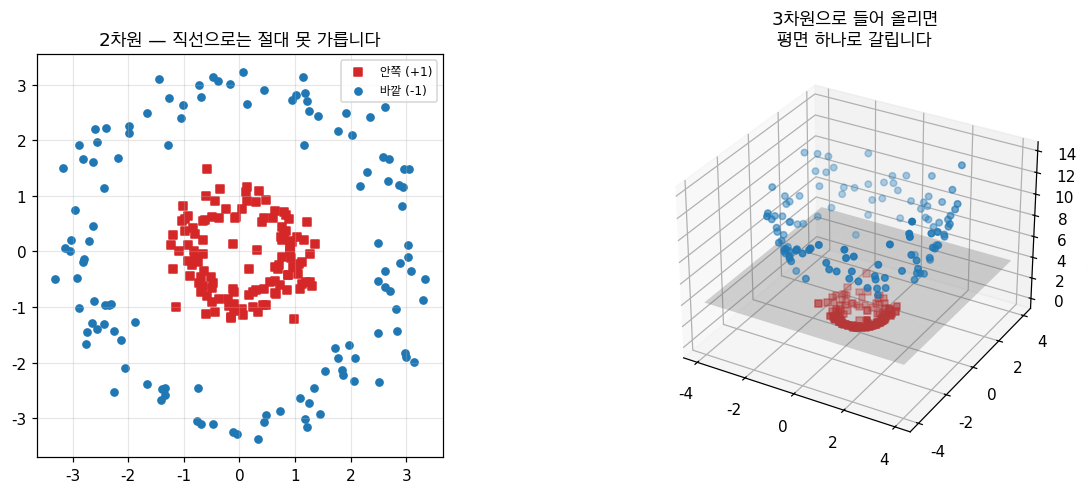

'z < 4.0 이면 안쪽' 이라는 평면 하나의 정확도: 100.0%

이 z를 우리가 손으로 만들었습니다. 커널은 이걸 '만들지 않고도' 해냅니다.


In [18]:
# ✨ 추가 — 도넛 데이터를 한 차원 들어 올려 봅니다
def 도넛데이터(시드=0, n=200):
    r = np.random.default_rng(시드)
    각 = r.uniform(0, 2*np.pi, n)
    반지름 = np.where(np.arange(n) < n//2, r.normal(1.0, 0.22, n), r.normal(3.0, 0.30, n))
    X = np.c_[반지름*np.cos(각), 반지름*np.sin(각)]
    y = np.where(np.arange(n) < n//2, 1, -1)
    p = r.permutation(n)
    return X[p], y[p]

X7, y7 = 도넛데이터(0, 240)
X7te, y7te = 도넛데이터(1, 240)

# 손으로 만든 세 번째 축: z = x1^2 + x2^2 (원점에서 얼마나 먼가)
z = X7[:, 0]**2 + X7[:, 1]**2

fig = plt.figure(figsize=(12, 4.6))
a1 = fig.add_subplot(1, 2, 1)
a1.scatter(X7[y7==1,0], X7[y7==1,1], c="tab:red", s=22, marker="s", label="안쪽 (+1)")
a1.scatter(X7[y7==-1,0], X7[y7==-1,1], c="tab:blue", s=22, label="바깥 (-1)")
a1.set_title("2차원 — 직선으로는 절대 못 가릅니다")
a1.legend(fontsize=8); a1.grid(alpha=0.3); a1.set_aspect("equal")

a2 = fig.add_subplot(1, 2, 2, projection="3d")
a2.scatter(X7[y7==1,0], X7[y7==1,1], z[y7==1], c="tab:red", s=18, marker="s")
a2.scatter(X7[y7==-1,0], X7[y7==-1,1], z[y7==-1], c="tab:blue", s=18)
G1, G2 = np.meshgrid(np.linspace(-4,4,10), np.linspace(-4,4,10))
a2.plot_surface(G1, G2, np.full_like(G1, 4.0), alpha=0.28, color="gray")
a2.set_zlabel("z = x1² + x2²")
a2.set_title("3차원으로 들어 올리면\n평면 하나로 갈립니다")
plt.tight_layout(); plt.show()

경계z = 4.0
정확도 = np.mean(np.where(z < 경계z, 1, -1) == y7)
print(f"'z < {경계z} 이면 안쪽' 이라는 평면 하나의 정확도: {정확도:.1%}")
print("\n이 z를 우리가 손으로 만들었습니다. 커널은 이걸 '만들지 않고도' 해냅니다.")

In [19]:
# ✨ 추가 — 진짜로 안 만들어도 되는지 확인합니다 (다항 2차 커널)
def 손으로올리기(X):
    # phi(x) = [x1², √2·x1·x2, x2², √2·x1, √2·x2, 1]  — (x·z+1)² 에 대응하는 좌표
    x1, x2 = X[:, 0], X[:, 1]
    s = math.sqrt(2.0)
    return np.c_[x1**2, s*x1*x2, x2**2, s*x1, s*x2, np.ones(len(X))]

a, b_ = X7[0], X7[1]

직접계산 = 손으로올리기(a[None])[0] @ 손으로올리기(b_[None])[0]   # 6차원으로 올린 뒤 내적
커널계산 = (a @ b_ + 1.0) ** 2                                   # 2차원에서 그냥 계산

print(f"점 a = {np.round(a,3)},  점 b = {np.round(b_,3)}\n")
print(f"① 6차원으로 올린 뒤 내적 : {직접계산:.10f}")
print(f"② 2차원에서 (a·b+1)² 계산: {커널계산:.10f}")
print(f"   차이 = {abs(직접계산-커널계산):.2e}\n")
print("=> 완전히 같습니다. 6차원 좌표를 한 번도 안 만들고 6차원 내적을 얻었습니다.")
print("   이게 커널 트릭입니다. 3차 다항이면 10차원, RBF면 무한 차원도 이렇게 처리합니다.")

점 a = [-0.093 -0.725],  점 b = [-1.347 -2.452]

① 6차원으로 올린 뒤 내적 : 8.4328695110
② 2차원에서 (a·b+1)² 계산: 8.4328695110
   차이 = 1.78e-15

=> 완전히 같습니다. 6차원 좌표를 한 번도 안 만들고 6차원 내적을 얻었습니다.
   이게 커널 트릭입니다. 3차 다항이면 10차원, RBF면 무한 차원도 이렇게 처리합니다.


---

## 8️⃣ 🔨 커널 SVM 만들기

> 🔗 **앞 절과 이어서** — 7절에서 "내적만 바꿔치기하면 된다"는 걸 확인했습니다.
> 그런데 **쌍대 문제를 실제로 어떻게 풀죠?** 5절의 경사하강법은 원 문제용이었습니다.
> 쌍대 문제를 푸는 표준 알고리즘이 **SMO**입니다.

> 📗 **원문** — "Build It: Step 3" (커널 함수) + ✨ **추가** (쌍대 문제 푸는 SMO 구현)

원문은 커널 함수 세 개만 코드로 줍니다. 여기서는 **그 커널로 실제로 학습까지** 해 보겠습니다.

쌍대 문제를 푸는 표준 알고리즘이 **SMO(Sequential Minimal Optimization)**입니다.
$\alpha$를 **한 번에 두 개씩** 골라서 그 둘만 최적으로 고치고, 이걸 반복합니다.

> 🧸 왜 두 개씩인가요? 제약 조건에 $\sum_i \alpha_i y_i = 0$이 있어서
> **하나만 바꾸면 이 조건이 깨집니다.** 두 개를 같이 움직여야 합이 유지돼요.
> (한 명이 돈을 내면 다른 한 명이 그만큼 받아야 총액이 유지되는 것과 같습니다.)

아래는 간소화 버전입니다. 원리를 보는 게 목적이라 휴리스틱은 뺐습니다.

In [20]:
# 📗 원문 Step 3 — 커널 함수 세 가지 (원문은 점 2개, 여기서는 행렬 전체를 한 번에)
def 선형커널(A, B):
    return A @ B.T

def 다항커널(A, B, 차수=3, c=1.0):
    return (A @ B.T + c) ** 차수

def RBF커널(A, B, 감마=0.5):
    # ||a-b||² = ||a||² + ||b||² - 2a·b  로 한 번에 계산합니다
    제곱거리 = (A**2).sum(1)[:, None] + (B**2).sum(1)[None, :] - 2 * (A @ B.T)
    return np.exp(-감마 * np.maximum(제곱거리, 0))

두점 = np.array([[0.0, 0.0], [1.0, 1.0]])
print("두 점 (0,0), (1,1) 사이의 커널 값")
print(f"  선형   K = {선형커널(두점, 두점)[0,1]:.4f}   (내적이 0이라 '관계 없음')")
print(f"  다항3차 K = {다항커널(두점, 두점)[0,1]:.4f}")
print(f"  RBF    K = {RBF커널(두점, 두점)[0,1]:.4f}   (거리 √2 만큼 떨어져 있음)")
print(f"\n자기 자신과의 RBF 커널 값 = {RBF커널(두점, 두점)[0,0]:.4f}  (거리 0 -> exp(0) = 1)")

두 점 (0,0), (1,1) 사이의 커널 값
  선형   K = 0.0000   (내적이 0이라 '관계 없음')
  다항3차 K = 1.0000
  RBF    K = 0.3679   (거리 √2 만큼 떨어져 있음)

자기 자신과의 RBF 커널 값 = 1.0000  (거리 0 -> exp(0) = 1)


In [21]:
# ✨ 추가 — 쌍대 문제를 푸는 간소화 SMO
class 커널SVM:
    def __init__(self, 커널=None, C=1.0, 반복=60, 오차=1e-3, 시드=0):
        self.커널 = 커널 or (lambda A, B: RBF커널(A, B, 0.5))
        self.C = C
        self.반복 = 반복
        self.오차 = 오차
        self.시드 = 시드

    def 학습(self, X, y):
        n = len(X)
        y = y.astype(float)
        K = self.커널(X, X)
        알파 = np.zeros(n)
        b = 0.0
        rng = np.random.default_rng(self.시드)

        for _ in range(self.반복):
            바뀐개수 = 0
            for i in range(n):
                f_i = (알파 * y) @ K[:, i] + b
                E_i = f_i - y[i]
                # KKT 조건을 어긴 알파만 고칩니다
                if (y[i]*E_i < -self.오차 and 알파[i] < self.C) or \
                   (y[i]*E_i > self.오차 and 알파[i] > 0):
                    j = int(rng.integers(0, n - 1))
                    if j >= i:
                        j += 1
                    f_j = (알파 * y) @ K[:, j] + b
                    E_j = f_j - y[j]
                    알파i옛, 알파j옛 = 알파[i], 알파[j]

                    # 알파j가 움직일 수 있는 범위 (제약 조건 때문에 상자 안에 갇힙니다)
                    if y[i] != y[j]:
                        L, H = max(0, 알파j옛 - 알파i옛), min(self.C, self.C + 알파j옛 - 알파i옛)
                    else:
                        L, H = max(0, 알파i옛 + 알파j옛 - self.C), min(self.C, 알파i옛 + 알파j옛)
                    if L >= H:
                        continue

                    eta = 2*K[i, j] - K[i, i] - K[j, j]
                    if eta >= 0:
                        continue

                    알파[j] = np.clip(알파j옛 - y[j]*(E_i - E_j)/eta, L, H)
                    if abs(알파[j] - 알파j옛) < 1e-5:
                        continue
                    # 합을 유지하려고 알파i를 반대로 움직입니다
                    알파[i] = 알파i옛 + y[i]*y[j]*(알파j옛 - 알파[j])

                    b1 = b - E_i - y[i]*(알파[i]-알파i옛)*K[i, i] - y[j]*(알파[j]-알파j옛)*K[i, j]
                    b2 = b - E_j - y[i]*(알파[i]-알파i옛)*K[i, j] - y[j]*(알파[j]-알파j옛)*K[j, j]
                    if 0 < 알파[i] < self.C:
                        b = b1
                    elif 0 < 알파[j] < self.C:
                        b = b2
                    else:
                        b = (b1 + b2) / 2
                    바뀐개수 += 1
            if 바뀐개수 == 0:
                break

        # 알파 > 0 인 점만 남깁니다. 이게 서포트 벡터입니다
        살아남음 = 알파 > 1e-6
        self.알파 = 알파[살아남음]
        self.서포트X = X[살아남음]
        self.서포트y = y[살아남음]
        self.b = b
        return self

    def 결정값(self, X):
        # 예측은 '서포트 벡터들과 얼마나 비슷한가'의 가중 합입니다
        return (self.알파 * self.서포트y) @ self.커널(self.서포트X, X) + self.b

    def 예측(self, X):
        return np.where(self.결정값(X) >= 0, 1, -1)

    def 점수(self, X, y):
        return np.mean(self.예측(X) == y)

print("커널 SVM 준비 완료")

커널 SVM 준비 완료


In [22]:
# 도넛 데이터에 커널별로 붙여 봅니다
커널목록 = [
    ("선형",        lambda A, B: 선형커널(A, B)),
    ("다항 2차",     lambda A, B: 다항커널(A, B, 차수=2, c=1.0)),
    ("다항 3차",     lambda A, B: 다항커널(A, B, 차수=3, c=1.0)),
    ("RBF γ=0.5",   lambda A, B: RBF커널(A, B, 0.5)),
]

print(f"{'커널':<14}{'훈련 정확도':>13}{'테스트 정확도':>15}{'서포트 벡터':>13}")
print("-" * 56)
학습된것 = []
for 이름, k in 커널목록:
    m = 커널SVM(커널=k, C=1.0, 반복=40).학습(X7, y7)
    학습된것.append((이름, m))
    print(f"{이름:<13}{m.점수(X7,y7):>13.1%}{m.점수(X7te,y7te):>15.1%}{len(m.알파):>13}")

선형점수 = 학습된것[0][1].점수(X7te, y7te)
print(f"\n=> 선형 커널은 도넛을 못 가릅니다 ({선형점수:.1%} — 찍기 50%보다 조금 나은 수준).")
print("   다항 2차부터 갈리기 시작합니다. z=x1²+x2² 를 만들 수 있으니 당연합니다.")
print("   RBF가 가장 깔끔합니다.")

커널                   훈련 정확도        테스트 정확도       서포트 벡터
--------------------------------------------------------
선형                   64.6%          66.2%          240
다항 2차               100.0%         100.0%           19
다항 3차               100.0%         100.0%           27
RBF γ=0.5           100.0%         100.0%           34

=> 선형 커널은 도넛을 못 가릅니다 (66.2% — 찍기 50%보다 조금 나은 수준).
   다항 2차부터 갈리기 시작합니다. z=x1²+x2² 를 만들 수 있으니 당연합니다.
   RBF가 가장 깔끔합니다.


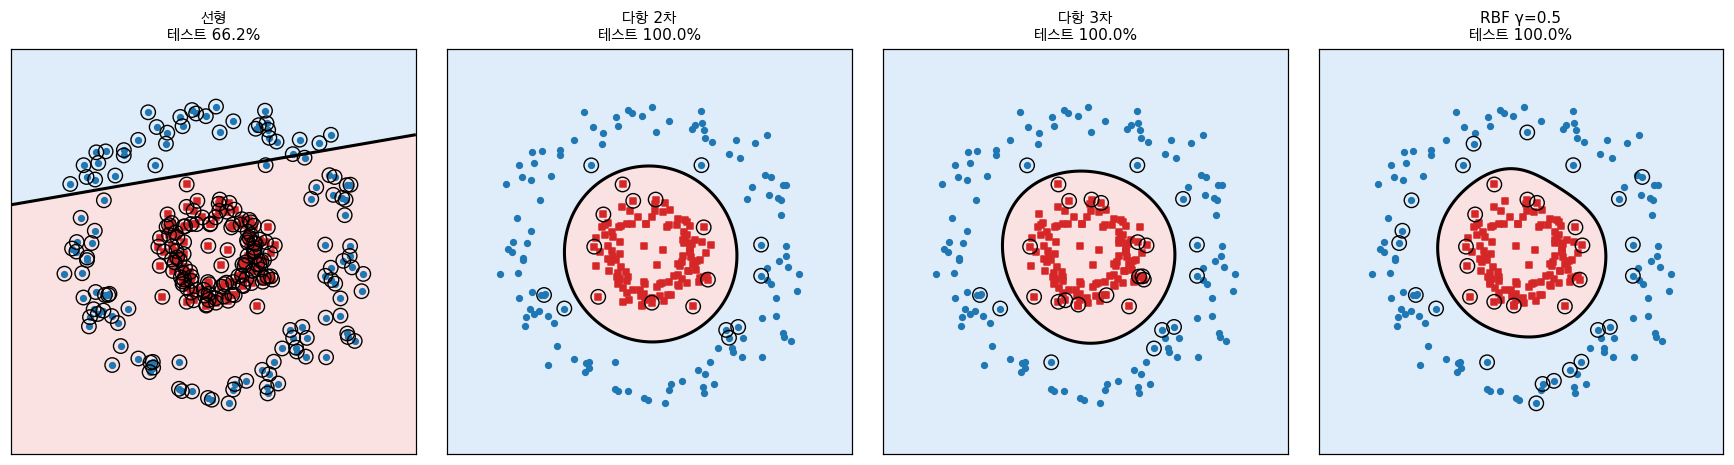

동그라미 = 서포트 벡터입니다. RBF에서는 경계 근처 점들이 뽑힌 게 보입니다.


In [23]:
# ✨ 추가 — 커널별 경계 모양을 그려 봅니다
fig, ax = plt.subplots(1, 4, figsize=(16, 4.1))
g1 = np.linspace(-4.5, 4.5, 220)
G1, G2 = np.meshgrid(g1, g1)
격자 = np.c_[G1.ravel(), G2.ravel()]

for a, (이름, m) in zip(ax, 학습된것):
    Z = m.결정값(격자).reshape(G1.shape)
    a.contourf(G1, G2, Z, levels=[-1e9, 0, 1e9], colors=["#cfe3f7", "#f9d3d3"], alpha=0.65)
    a.contour(G1, G2, Z, levels=[0], colors="k", linewidths=2)
    a.scatter(X7[y7==1,0], X7[y7==1,1], c="tab:red", s=14, marker="s")
    a.scatter(X7[y7==-1,0], X7[y7==-1,1], c="tab:blue", s=14)
    a.scatter(m.서포트X[:,0], m.서포트X[:,1], s=90, facecolors="none",
              edgecolors="black", linewidths=0.9)
    a.set_title(f"{이름}\n테스트 {m.점수(X7te,y7te):.1%}", fontsize=10)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print("동그라미 = 서포트 벡터입니다. RBF에서는 경계 근처 점들이 뽑힌 게 보입니다.")

> ✨ **추가** — RBF의 γ를 바꾸면 어떻게 되는지 봅니다. 이게 SVM에서 가장 중요한 손잡이입니다.

In [24]:
# ✨ 추가 — γ(감마)를 바꿔 가며 과소적합 -> 과적합을 봅니다
print(f"{'γ':>8}{'훈련 정확도':>13}{'테스트 정확도':>15}{'서포트 벡터':>13}   상태")
print("-" * 66)
감마결과 = []
for g in [0.001, 0.01, 0.1, 0.5, 2.0, 10.0, 50.0]:
    m = 커널SVM(커널=lambda A, B, gg=g: RBF커널(A, B, gg), C=1.0, 반복=40).학습(X7, y7)
    감마결과.append((g, m.점수(X7,y7), m.점수(X7te,y7te), len(m.알파)))

최고점수 = max(r[2] for r in 감마결과)
좋은감마들 = [r[0] for r in 감마결과 if r[2] == 최고점수]
for g, tr, te, ns in 감마결과:
    if g in 좋은감마들:
        상태 = "<- 가장 좋음"
    elif g < min(좋은감마들):
        상태 = "경계가 너무 밋밋함 (과소적합)"
    else:
        상태 = "테스트가 떨어짐 (과적합)"
    print(f"{g:>8}{tr:>13.1%}{te:>15.1%}{ns:>13}   {상태}")

기준 = [r for r in 감마결과 if r[0] == max(좋은감마들)][0]
마지막 = 감마결과[-1]
print(f"\n=> γ를 가장 좋은 값({max(좋은감마들)})보다 더 키우면 테스트가 떨어집니다"
      f" ({기준[2]:.1%} -> {마지막[2]:.1%}).")
print("   γ가 크다 = '아주 가까운 점만 이웃으로 친다' = 점 하나하나를 외운다는 뜻입니다.")
print(f"   서포트 벡터도 함께 늘어납니다 ({기준[3]}개 -> {마지막[3]}개). 외울 게 많아진 거죠.")
print(f"   반대로 γ가 너무 작으면({감마결과[0][0]}) 아예 학습이 안 됩니다"
      f" (훈련 정확도 {감마결과[0][1]:.1%}). 모든 점이 다 '비슷해' 보이니까요.")
print("   ⚠️ 실무에서는 C와 γ를 반드시 같이 튜닝합니다 (그리드 서치).")

       γ       훈련 정확도        테스트 정확도       서포트 벡터   상태
------------------------------------------------------------------
   0.001        50.0%          50.0%          240   경계가 너무 밋밋함 (과소적합)
    0.01       100.0%          97.9%          238   경계가 너무 밋밋함 (과소적합)
     0.1       100.0%         100.0%           37   <- 가장 좋음
     0.5       100.0%         100.0%           34   <- 가장 좋음
     2.0       100.0%          99.6%           82   테스트가 떨어짐 (과적합)
    10.0       100.0%          99.6%          174   테스트가 떨어짐 (과적합)
    50.0       100.0%          95.8%          227   테스트가 떨어짐 (과적합)

=> γ를 가장 좋은 값(0.5)보다 더 키우면 테스트가 떨어집니다 (100.0% -> 95.8%).
   γ가 크다 = '아주 가까운 점만 이웃으로 친다' = 점 하나하나를 외운다는 뜻입니다.
   서포트 벡터도 함께 늘어납니다 (34개 -> 227개). 외울 게 많아진 거죠.
   반대로 γ가 너무 작으면(0.001) 아예 학습이 안 됩니다 (훈련 정확도 50.0%). 모든 점이 다 '비슷해' 보이니까요.
   ⚠️ 실무에서는 C와 γ를 반드시 같이 튜닝합니다 (그리드 서치).


---

## 9️⃣ SVR — 숫자를 예측하는 SVM

> 🔗 **앞 절과 이어서** — 여기까지 전부 **분류**였습니다. 숫자 예측은요?
> 4절의 힌지 손실이 "충분히 맞혔으면 손 뗀다"였죠.
> **그 발상을 회귀로 옮기면** "충분히 가까우면 손 뗀다"가 됩니다.

> 📗 **원문** — "SVM for regression (SVR)"

SVM으로 **분류가 아니라 숫자 예측**도 할 수 있습니다. 발상이 재미있어요.

- **분류 SVM**: "경계에서 최대한 멀리 떨어뜨려라"
- **SVR**: "데이터를 폭 $\epsilon$짜리 **튜브(관)** 안에 다 담아라"

$$\min \ \tfrac12\|\mathbf{w}\|^2 + C\sum_i(\xi_i + \xi_i^*)$$

**튜브 안에 들어온 점은 손실이 0입니다.** 튜브 밖으로 나간 만큼만 벌점을 줍니다.

### 🧸 비유 — 넉넉한 배관에 데이터를 통과시키기

2단원 선형 회귀는 "모든 점에서 오차 제곱을 최소로" 했습니다. 점 하나하나를 다 신경 씁니다.
SVR은 **"이 정도 오차는 안 틀린 걸로 치자"**고 선언합니다. 그 '이 정도'가 $\epsilon$입니다.

| $\epsilon$ | 결과 |
| --- | --- |
| **넓은 튜브** | 서포트 벡터 적음 → 매끄러운 예측 |
| **좁은 튜브** | 서포트 벡터 많음 → 데이터에 더 밀착 |

> 이건 **힌지 손실의 회귀 버전**이라고 보면 정확합니다.
> 힌지가 "충분히 맞혔으면 손 뗀다"였듯, SVR은 "충분히 가까우면 손 뗀다"입니다.

> ✨ **추가** — 원문 연습문제 5번(sin 곡선에 SVR 맞추고 튜브 그리기)을 직접 풀어 봅니다.

    ε (튜브 폭)       서포트 벡터      튜브 밖 점        평균 절대 오차
-------------------------------------------------------
        0.02          110         101          0.1220
         0.2           39          33          0.1452
         0.6            9           8          0.2421


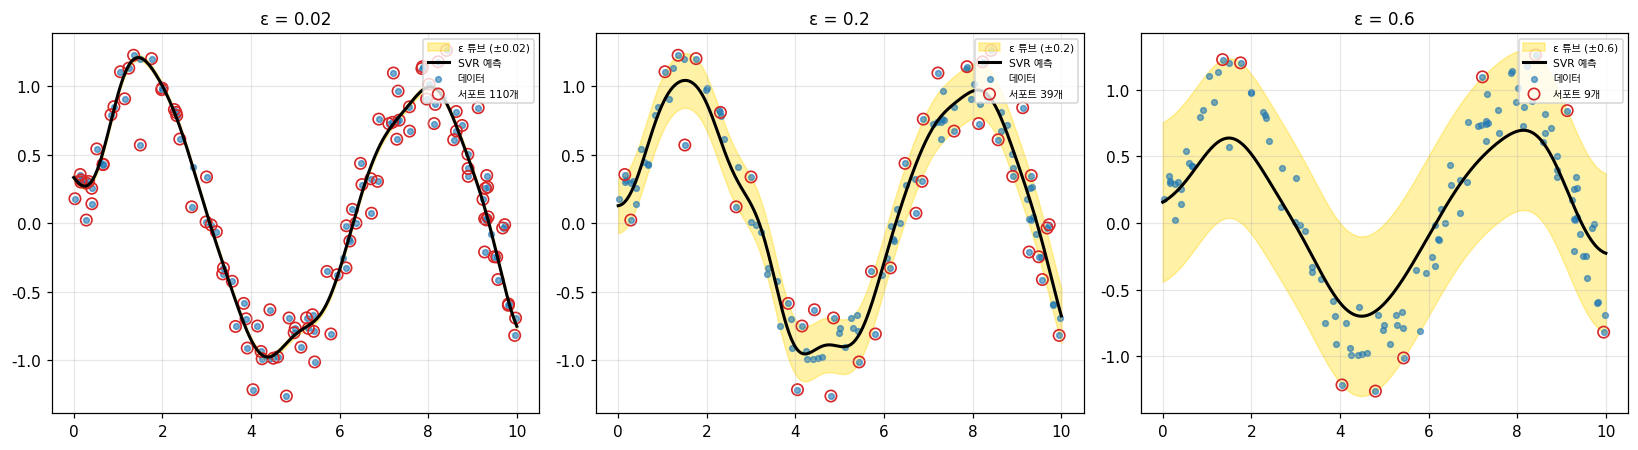


=> 튜브가 넓을수록 서포트 벡터가 줄어듭니다. 튜브 안에 들어온 점은 손실이 0이니까요.
   빨간 동그라미(서포트 벡터)가 전부 튜브 가장자리나 바깥에 있는 게 보이시나요?


In [25]:
# ✨ 추가 — 원문 연습문제 5번: y = sin(x) + 잡음 에 SVR 맞추기
from sklearn.svm import SVR

r = np.random.default_rng(0)
X9 = np.sort(r.uniform(0, 10, 120))[:, None]
y9 = np.sin(X9.ravel()) + r.normal(0, 0.18, 120)
격자9 = np.linspace(0, 10, 400)[:, None]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
print(f"{'ε (튜브 폭)':>12}{'서포트 벡터':>13}{'튜브 밖 점':>12}{'평균 절대 오차':>16}")
print("-" * 55)
for a, eps in zip(ax, [0.02, 0.2, 0.6]):
    m = SVR(kernel="rbf", C=10.0, gamma=1.0, epsilon=eps).fit(X9, y9)
    예측 = m.predict(X9)
    밖 = int((np.abs(예측 - y9) > eps).sum())
    mae = np.mean(np.abs(예측 - y9))
    print(f"{eps:>12}{len(m.support_):>13}{밖:>12}{mae:>16.4f}")

    곡선 = m.predict(격자9)
    a.fill_between(격자9.ravel(), 곡선-eps, 곡선+eps, color="gold", alpha=0.35,
                   label=f"ε 튜브 (±{eps})")
    a.plot(격자9, 곡선, c="black", lw=2, label="SVR 예측")
    a.scatter(X9, y9, s=14, c="tab:blue", alpha=0.6, label="데이터")
    a.scatter(X9[m.support_], y9[m.support_], s=55, facecolors="none",
              edgecolors="tab:red", linewidths=1.1, label=f"서포트 {len(m.support_)}개")
    a.set_title(f"ε = {eps}", fontsize=11)
    a.legend(fontsize=7, loc="upper right"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n=> 튜브가 넓을수록 서포트 벡터가 줄어듭니다. 튜브 안에 들어온 점은 손실이 0이니까요.")
print("   빨간 동그라미(서포트 벡터)가 전부 튜브 가장자리나 바깥에 있는 게 보이시나요?")

---

## 🔟 실무 — sklearn과 스케일링

> 🔗 **앞 절과 이어서** — 여기까지 전부 직접 만들었습니다.
> 실무에서는 라이브러리를 씁니다. 다만 **5절에서 본 스케일링 문제**만은 직접 챙겨야 합니다.

> 📗 **원문** — "Use It"

```python
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale")),
])
```

### 📗 원문이 강조한 두 가지

1. **무조건 스케일링하세요.** 5절에서 확인했듯이 단위만 달라도 성능이 무너집니다.
   `Pipeline`을 쓰면 훈련 데이터의 평균/표준편차가 테스트에 새어 나가지 않습니다.

2. **데이터가 크면 `SVC` 말고 `LinearSVC`.**
   - `SVC` = 쌍대 문제 → $O(n^2) \sim O(n^3)$. 10만 개 넘어가면 사실상 못 씁니다.
   - `LinearSVC` = 원 문제 (우리가 5절에서 만든 것) → 에폭당 $O(nd)$

In [26]:
# 📗 원문 Use It — 파이프라인으로 제대로 쓰기
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
import time

X10, y10 = 도넛데이터(0, 400)
X10te, y10te = 도넛데이터(1, 400)

clf = Pipeline([("scaler", StandardScaler()),
                ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))]).fit(X10, y10)
print(f"RBF 파이프라인 테스트 정확도: {clf.score(X10te, y10te):.4f}")
print(f"서포트 벡터 개수 (클래스별): {clf['svm'].n_support_}")

print("\n[원문 권장 — C와 γ 그리드 서치]")
격자탐색 = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("svm", SVC(kernel="rbf"))]),
    {"svm__C": [0.1, 1, 10, 100], "svm__gamma": [0.01, 0.1, 1, 10]},
    cv=5, n_jobs=-1).fit(X10, y10)
print(f"가장 좋은 조합: {격자탐색.best_params_}")
print(f"교차검증 점수: {격자탐색.best_score_:.4f} / 테스트: {격자탐색.score(X10te, y10te):.4f}")

RBF 파이프라인 테스트 정확도: 1.0000
서포트 벡터 개수 (클래스별): [15 12]

[원문 권장 — C와 γ 그리드 서치]
가장 좋은 조합: {'svm__C': 0.1, 'svm__gamma': 1}
교차검증 점수: 1.0000 / 테스트: 1.0000


In [27]:
# ✨ 추가 — SVC와 LinearSVC의 학습 시간이 데이터 크기에 따라 어떻게 벌어지는지
print(f"{'데이터 크기':>12}{'SVC (초)':>12}{'LinearSVC (초)':>16}{'배율':>9}")
print("-" * 51)
for n in [500, 2000, 8000]:
    Xb, yb = 섞인데이터(0, n)
    t0 = time.time(); SVC(kernel="linear", C=1.0).fit(Xb, yb); t1 = time.time()
    LinearSVC(C=1.0, max_iter=5000, dual=False).fit(Xb, yb); t2 = time.time()
    print(f"{n:>12}{t1-t0:>12.3f}{t2-t1:>16.3f}{(t1-t0)/(t2-t1):>9.1f}x")

print("\n=> 데이터가 커질수록 SVC가 훨씬 빠르게 느려집니다.")
print("   원문 말대로 큰 데이터에는 LinearSVC(원 문제)를 씁니다.")
print("   다만 LinearSVC는 커널을 못 씁니다. 곡선 경계가 필요하면 SVC를 써야 합니다.")

      데이터 크기     SVC (초)   LinearSVC (초)       배율
---------------------------------------------------
         500       0.003           0.001      2.6x
        2000       0.016           0.001     18.2x
        8000       0.295           0.002    130.8x

=> 데이터가 커질수록 SVC가 훨씬 빠르게 느려집니다.
   원문 말대로 큰 데이터에는 LinearSVC(원 문제)를 씁니다.
   다만 LinearSVC는 커널을 못 씁니다. 곡선 경계가 필요하면 SVC를 써야 합니다.


---

## 1️⃣1️⃣ SVM은 왜 딥러닝에 밀렸나

> 🔗 **마무리** — SVM은 한때 분류의 왕이었습니다. 왜 자리를 내줬을까요?
> 그리고 **아직도 SVM이 이기는 곳**은 어디일까요?

> 📗 **원문** — "Why SVMs lost to deep learning (and when they still win)"

SVM은 1990년대 후반부터 2010년대 초반까지 **분류의 왕**이었습니다. 그런데 밀렸습니다.

| 항목 | SVM | 딥러닝 |
| --- | --- | --- |
| 특징 만들기 | **사람이 직접 해야 함** | 알아서 배움 |
| 확장성 | 커널은 $O(n^2)\sim O(n^3)$ | SGD로 에폭당 $O(n)$ |
| 이미지·텍스트·음성 | 손으로 만든 특징 필요 | **원본에서 바로 배움** |
| 큰 데이터 (10만+) | 느림 | 잘 됨 |
| GPU | 별 이득 없음 | **엄청난 가속** |

### 🧸 한 줄 요약

> **SVM은 "잘 정리된 특징이 주어지면 최적의 선을 긋는" 데 천재입니다.
> 딥러닝은 "특징 자체를 만들어내는" 데 천재입니다.**

사진 픽셀을 SVM에 그냥 넣으면 잘 안 됩니다. 픽셀 값 자체엔 '고양이다움'이 없으니까요.
예전엔 사람이 SIFT, HOG 같은 특징을 손으로 설계해서 SVM에 넣었습니다. CNN이 이 단계를 없앴습니다.

### 📗 그래도 SVM이 이기는 곳

- **데이터가 작을 때** (수백~수천 개). 딥러닝은 이 정도로는 학습이 안 됩니다.
- **차원이 높고 희소한 데이터** (TF-IDF 텍스트 등)
- **수학적 보장이 필요할 때** (마진 기반 일반화 경계)
- **훈련 시간이 아주 짧아야 할 때** (선형 SVM은 매우 빠릅니다)
- **이상 탐지** (One-Class SVM)

> ✨ **추가** — '데이터가 적을 때 SVM이 유리하다'가 정말인지 재 봅니다.

In [28]:
# ✨ 추가 — 훈련 데이터 개수를 바꿔 가며 SVM vs 신경망
from sklearn.datasets import make_moons
from sklearn.neural_network import MLPClassifier

def 어려운데이터(시드, n, 잡음특징=6):
    # 초승달 두 개 + 잡음. 게다가 아무 의미 없는 특징 6개를 덧붙입니다
    # (실제 데이터는 늘 이렇습니다. 쓸모없는 열이 잔뜩 섞여 있어요)
    X, y = make_moons(n_samples=n, noise=0.30, random_state=시드)
    r = np.random.default_rng(시드)
    X = np.c_[X, r.normal(size=(n, 잡음특징))]
    return X, np.where(y == 1, 1, -1)

X평가, y평가 = 어려운데이터(999, 2000)

print("특징 8개 중 2개만 의미가 있는 데이터입니다. 시드 5개 평균이에요.\n")
print(f"{'훈련 개수':>10}{'SVM (RBF)':>13}{'신경망 (MLP)':>15}{'차이':>10}{'이긴 쪽':>10}")
print("-" * 60)
크기결과 = []
for n in [30, 60, 120, 300, 800]:
    s점수, d점수 = [], []
    for sd in range(5):
        Xs, ys = 어려운데이터(sd, n)
        s점수.append(Pipeline([("sc", StandardScaler()),
                              ("m", SVC(kernel="rbf", C=1.0, gamma="scale"))
                              ]).fit(Xs, ys).score(X평가, y평가))
        d점수.append(Pipeline([("sc", StandardScaler()),
                              ("m", MLPClassifier(hidden_layer_sizes=(32, 32),
                                                  max_iter=2000, random_state=0))
                              ]).fit(Xs, ys).score(X평가, y평가))
    a, b_ = np.mean(s점수), np.mean(d점수)
    크기결과.append((n, a, b_))
    이긴쪽 = "SVM" if a > b_ else "신경망"
    print(f"{n:>10}{a:>13.1%}{b_:>15.1%}{a-b_:>+10.1%}{이긴쪽:>11}")

역전 = [n for n, a, b_ in 크기결과 if b_ > a]
print(f"\n=> 데이터가 적을 때는 SVM이 앞섭니다 (30개일 때 {크기결과[0][1]-크기결과[0][2]:+.1%}).")
if 역전:
    print(f"   그러다 {역전[0]}개쯤에서 신경망이 따라잡고 역전합니다.")
print("   원문 표가 말하는 그림 그대로입니다.")
print("   ⚠️ 단, 이건 특징이 8개뿐인 장난감 문제입니다.")
print("      진짜 차이는 이미지·텍스트처럼 '특징을 만들어야 하는' 데이터에서 벌어집니다.")

특징 8개 중 2개만 의미가 있는 데이터입니다. 시드 5개 평균이에요.

     훈련 개수    SVM (RBF)      신경망 (MLP)        차이      이긴 쪽
------------------------------------------------------------
        30        78.6%          75.2%     +3.4%        SVM
        60        80.9%          77.9%     +2.9%        SVM
       120        83.4%          79.9%     +3.6%        SVM
       300        84.9%          83.1%     +1.8%        SVM
       800        86.1%          87.5%     -1.4%        신경망

=> 데이터가 적을 때는 SVM이 앞섭니다 (30개일 때 +3.4%).
   그러다 800개쯤에서 신경망이 따라잡고 역전합니다.
   원문 표가 말하는 그림 그대로입니다.
   ⚠️ 단, 이건 특징이 8개뿐인 장난감 문제입니다.
      진짜 차이는 이미지·텍스트처럼 '특징을 만들어야 하는' 데이터에서 벌어집니다.


---

## 1️⃣2️⃣ 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 진짜 무슨 뜻인가 |
| --- | --- |
| **마진 (margin)** | 경계와 가장 가까운 점 사이의 거리. SVM은 이걸 최대로 만듭니다 |
| **최대 마진** | "가장 넓은 길을 내는 선을 고른다"는 원칙 |
| **서포트 벡터** | 길가에 걸쳐 있는 소수의 점. **얘들만 경계를 정합니다** |
| **힌지 손실** | $\max(0, 1-yf)$. 충분히 맞혔으면 **정확히 0** |
| **C 값** | 실수 하나가 얼마나 비싼가. **크면 좁은 길·과적합, 작으면 넓은 길·과소적합** |
| **소프트 마진** | 실수를 봐주는 SVM. 섞인 데이터를 다룰 수 있게 해 줍니다 |
| **슬랙 변수 $\xi_i$** | 점 $i$를 얼마나 봐줬는가. 잘 맞힌 점은 0 |
| **커널 트릭** | 고차원에 **안 가고도** 고차원 내적을 계산하는 방법 |
| **선형 커널** | $x\cdot z$. 그냥 내적. 직선으로 갈릴 때 |
| **다항 커널** | $(x\cdot z+c)^d$. 특징들의 곱 조합까지 봅니다 |
| **RBF 커널** | $\exp(-\gamma\|x-z\|^2)$. **무한 차원.** 어떤 매끄러운 곡선도 만듭니다 |
| **$\gamma$ (감마)** | RBF에서 "이웃을 얼마나 좁게 볼 건가". 크면 꼬불꼬불(과적합) |
| **쌍대 형식** | 점끼리의 내적만으로 쓴 문제. **커널을 쓸 수 있게 해 주는 열쇠** |
| **SVR** | 숫자 예측용 SVM. 폭 $\epsilon$ 튜브 안의 점은 손실 0 |

---

## ✅ 이 단원 요약 (5줄)

1. **가장 넓은 길**을 내는 선이 가장 좋은 선입니다. 새 점이 들어와도 여유가 있으니까요.
2. 길가에 걸친 **서포트 벡터 몇 개**만 경계를 정합니다. 나머지는 지워도 됩니다.
3. **C**로 "실수를 얼마나 봐줄지"를 정합니다. 크면 과적합, 작으면 과소적합.
4. **힌지 손실**은 충분히 맞힌 점의 손실을 정확히 0으로 만듭니다. 그래서 서포트 벡터만 남습니다.
5. **커널 트릭**으로 고차원에 안 가고도 곡선 경계를 만듭니다. 잘 모르겠으면 RBF.

---

## 📝 연습문제

> 📗 **원문** — "Exercises" (몇 번은 본문에서 이미 풀었습니다)

1. 2차원 선형 분리 데이터를 만들고 `선형SVM`으로 학습한 뒤, 서포트 벡터가 정말 경계에서 가장 가까운 점인지 확인해 보세요. → *6절 참고*
2. 잡음이 있는 데이터에서 C를 0.001부터 1000까지 바꿔 가며 경계를 그려 보세요. → *3절에서 함*
3. 원형 경계 데이터에서 선형 SVM이 실패하는 걸 보이고, RBF 커널로 갈리는 걸 확인하세요. → *7·8절에서 함*
4. 같은 데이터에 SVM과 로지스틱 회귀를 학습시키고, **경계 결정에 실제로 기여한 점의 개수**를 세어 비교해 보세요.
5. SVR을 밑바닥부터 구현해 보세요 (ε-무감각 손실). → *9절은 sklearn을 썼습니다. 힌지 손실 코드를 고쳐 보세요.*

### ✨ 추가 도전 과제

6. 5절의 `선형SVM`에 **미니배치 SGD**를 넣어 보세요. 큰 데이터에서 얼마나 빨라지나요?
7. 8절의 `커널SVM`으로 **γ와 C를 동시에** 바꿔 가며 표를 만들고, 어떤 조합이 좋은지 찾아보세요.
8. 4단원의 랜덤 포레스트와 이 단원의 RBF SVM을 **같은 데이터**에 붙여 비교해 보세요. 어느 쪽이 이기나요? 왜 그럴까요?

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [Cortes & Vapnik: Support-vector networks (1995)](https://link.springer.com/article/10.1007/BF00994018) — SVM 원조 논문
- [Vapnik: The Nature of Statistical Learning Theory (1995)](https://link.springer.com/book/10.1007/978-1-4757-3264-1) — 통계 학습 이론의 교과서
- [Platt: Sequential Minimal Optimization (1998)](https://www.microsoft.com/en-us/research/publication/sequential-minimal-optimization-a-fast-algorithm-for-training-support-vector-machines/) — 8절에서 만든 SMO의 원 논문
- [scikit-learn SVM 문서](https://scikit-learn.org/stable/modules/svm.html)
- [LIBSVM](https://www.csie.ntu.edu.tw/~cjlin/libsvm/) — 대부분의 SVM 구현이 쓰는 C++ 라이브러리